# Campaign property trends

Manual, read-only exploration of every `data/results/begins_*/agg.csv`. Each marker is a sample mean and each error bar is **±1 intra-sample standard deviation**. Actual raw specimen timestamps are used when available; processing timestamps are the fallback.

Run the cells from top to bottom. Edit only the settings cell for normal use.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Works whether Jupyter starts in the repository root or EVALUATE/.
repo_root = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
evaluate_dir = repo_root / 'EVALUATE'
if str(evaluate_dir) not in sys.path:
    sys.path.insert(0, str(evaluate_dir))

from campaign_trends import (
    available_properties, export_campaign, load_campaign_data,
    plot_properties, select_campaign,
)

## Settings

In [2]:
PROPERTIES = [
    'Thickness',
    'Elastic Modulus',
    'Yield Strength',
    'Pore Fraction',
    'Creep Strain',
    'Strain at 50 bar',
]
START = None       # Example: '2026-08-10'
END = None         # Example: '2026-08-22' (the full day is included)
CAMPAIGNS = None   # Example: ['2026-08-20-exploration-mode']; None means all
CONNECT_POINTS = True
SAVE_OUTPUTS = False
CHEMISTRY_FILTER = 'Polysulfone / PolarClean (inferred)'  # Set to None for every chemistry

## Campaign interpretation

The dated `llm.csv` suggestions identify the campaign intent as follows:

- **Aug 11–20 afternoon:** directed mechanical optimization. The suggestions repeatedly state the primary objective is to maximize Elastic Modulus and the secondary objective is to minimize Strain at 50 bar. The 17 wt%, additive-free formulation is treated as Polysulfone/PolarClean.
- **From Aug 20 exploration-mode onward:** deliberate design-space exploration. The LLM suggestions explicitly prioritize sparse-region coverage, while retaining modulus/strain as downstream objectives.

These labels are campaign-level interpretations, not analytical identification of the chemicals. Change `PHASES` below if laboratory records provide more exact boundaries. Dashed lines are the running best achieved value: upper envelope for maximization and lower envelope for minimization.

In [3]:
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Boundaries inferred from the dated LLM suggestions. None means extend to plot edge.
PHASES = [
    dict(start=None, end='2026-08-20 16:30',
         label='Polysulfone / PolarClean\nmaximize modulus; minimize strain', color='#7fc8a9'),
    dict(start='2026-08-20 16:30', end=None,
         label='Polysulfone / PolarClean\nexplorative design-space coverage', color='#91b7e8'),
]

# Direction is based on the objectives stated in the LLM suggestions. Add/edit as needed.
GOAL_DIRECTION = {
    'Elastic Modulus': 'maximize',
    'Yield Strength': 'maximize',
    'Strain at 50 bar': 'minimize',
    'Strain at 80 bar': 'minimize',
    'Strain at 150 bar': 'minimize',
    'Strain at 500 bar': 'minimize',
}

def infer_chemistry(row):
    """Notebook-only heuristic supplied with the campaign context."""
    polymer = pd.to_numeric(row.get('polymer_wt'), errors='coerce')
    additive = pd.to_numeric(row.get('additive_wt'), errors='coerce')
    name = str(row.get('condition', ''))
    if (pd.notna(polymer) and polymer >= 20 and pd.notna(additive) and additive > 0) or (name.startswith('21-') and not name.startswith('21-0add')):
        return 'Primospire / NMP + PVP (inferred)'
    if (pd.notna(polymer) and polymer >= 20) or name.startswith('21-'):
        return 'Primospire / NMP, no PVP (inferred)'
    if pd.notna(polymer) and polymer <= 17:
        return 'Polysulfone / PolarClean (inferred)'
    return 'Unclassified formulation'

def _shade_phases(ax, points):
    for phase in PHASES:
        mask = pd.Series(True, index=points.index)
        if phase['start'] is not None:
            mask &= points['sample_time'] >= pd.Timestamp(phase['start'])
        if phase['end'] is not None:
            mask &= points['sample_time'] < pd.Timestamp(phase['end'])
        phase_iterations = points.loc[mask, 'iteration']
        if not phase_iterations.empty:
            ax.axvspan(phase_iterations.min() - 0.5, phase_iterations.max() + 0.5,
                       color=phase['color'], alpha=0.18, zorder=0)

def plot_detailed_campaign(data, properties, color_column, color_label, *,
                           nitrogen_markers=False, columns=2, connect_points=True, cmap='viridis'):
    """Plot one campaign view with a selectable color variable and fixed marker size."""
    import math
    properties = list(properties)
    columns = max(1, min(columns, len(properties)))
    rows = math.ceil(len(properties) / columns)
    fig, grid = plt.subplots(rows, columns, figsize=(8.5 * columns, 5.2 * rows), squeeze=False)
    axes = list(grid.flat)
    valid_times = data['sample_time'].dropna()
    minimum_time, maximum_time = valid_times.min(), valid_times.max()
    enriched = data.copy()
    enriched['chemistry'] = enriched.apply(infer_chemistry, axis=1)
    enriched = enriched.sort_values('sample_time').reset_index(drop=True)
    enriched['iteration'] = enriched.index + 1
    color_values = pd.to_numeric(enriched[color_column], errors='coerce')
    color_min, color_max = color_values.min(), color_values.max()
    if color_min == color_max:
        color_min -= 0.5
        color_max += 0.5
    normalization = plt.Normalize(color_min, color_max)
    color_map = plt.get_cmap(cmap)
    def nitrogen_is_on(value):
        return value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}
    for ax, prop in zip(axes, properties):
        mean_col, sd_col = f'{prop} Mean', f'{prop} SD'
        points = enriched.dropna(subset=['sample_time', mean_col]).sort_values('sample_time')
        _shade_phases(ax, enriched)
        if connect_points:
            ax.plot(points['iteration'], points[mean_col], color='#707070', lw=0.9, alpha=0.55, zorder=2)
        point_color_values = pd.to_numeric(points[color_column], errors='coerce').fillna(color_values.median())
        point_colors = color_map(normalization(point_color_values))
        for (_, point), color in zip(points.iterrows(), point_colors):
            error = pd.to_numeric(pd.Series([point.get(sd_col)]), errors='coerce').fillna(0).iloc[0]
            marker = ('o' if nitrogen_is_on(point.get('nitrogen')) else 's') if nitrogen_markers else 'o'
            ax.errorbar(point['iteration'], point[mean_col], yerr=error,
                        fmt=marker, linestyle='none', color=color, ecolor=color,
                        markeredgecolor='black', markeredgewidth=1.2,
                        markersize=11, capsize=4, elinewidth=1.3, zorder=3)
        direction = GOAL_DIRECTION.get(prop)
        if direction:
            values = pd.to_numeric(points[mean_col], errors='coerce')
            running_best = values.cummax() if direction == 'maximize' else values.cummin()
            ax.step(points['iteration'], running_best, where='post', color='#b21f35',
                    linestyle='--', linewidth=1.6,
                    label=f'Running best ({direction})', zorder=4)
        ax.set_title(prop, fontsize=20, fontweight='semibold', pad=12)
        ax.set_xlabel('Iteration (chronological order)', fontsize=16, labelpad=9)
        ax.set_ylabel(f'{prop} (mean ± SD)', fontsize=13, labelpad=8)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.label.set_size(16)
        ax.grid(True, alpha=0.22)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xlim(0.5, len(enriched) + 0.5)
    for ax in axes[len(properties):]:
        ax.remove()
    phase_handles = [Patch(facecolor=p['color'], alpha=.25, label=p['label']) for p in PHASES]
    goal_handle = plt.Line2D([], [], color='#b21f35', linestyle='--', label='Optimization goal: running best')
    nitrogen_handles = [
        plt.Line2D([], [], marker='o', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen on'),
        plt.Line2D([], [], marker='s', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen off'),
    ]
    legend_handles = phase_handles + [goal_handle] + (nitrogen_handles if nitrogen_markers else [])
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, 0.12),
               ncol=4, frameon=False, fontsize=13, labelspacing=1.0, columnspacing=1.5)
    color_scale = plt.cm.ScalarMappable(norm=normalization, cmap=color_map)
    color_scale.set_array([])
    # A dedicated axis keeps the color scale clear of the right-hand plots.
    fig.subplots_adjust(left=0.09, right=0.87, bottom=0.25, top=0.90, wspace=0.32, hspace=0.42)
    colorbar_axis = fig.add_axes([0.915, 0.25, 0.018, 0.55])
    colorbar = fig.colorbar(color_scale, cax=colorbar_axis)
    colorbar.set_label(color_label, fontsize=16, labelpad=14)
    colorbar.ax.tick_params(labelsize=14)
    fig.suptitle(f'Polysulfone / PolarClean properties — color: {color_label}',
                 fontsize=22, fontweight='semibold')
    return fig, axes[:len(properties)], enriched

In [4]:
all_data = load_campaign_data(repo_root / 'data' / 'results', repo_root / 'data' / 'raw')
campaign = select_campaign(all_data, start=START, end=END, campaigns=CAMPAIGNS)
campaign['chemistry'] = campaign.apply(infer_chemistry, axis=1)
if CHEMISTRY_FILTER is not None:
    campaign = campaign[campaign['chemistry'] == CHEMISTRY_FILTER].copy()
property_mean_columns = [f'{prop} Mean' for prop in PROPERTIES]
campaign = campaign[campaign[property_mean_columns].notna().any(axis=1)].copy()
campaign = campaign[pd.to_numeric(campaign['Thickness Mean'], errors='coerce') >= 70].copy()
# Remove the incomplete 10 wt% baseline; the retained PolarClean campaign spans 13–17 wt%.
campaign = campaign[pd.to_numeric(campaign['polymer_wt'], errors='coerce') >= 13].copy()
# Split exposure into state-specific durations so nitrogen-on and nitrogen-off slopes can differ.
campaign['nitrogen_binary'] = campaign['nitrogen'].map(
    lambda value: 1 if (value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}) else 0
)
campaign['nitrogen_exposure_time'] = campaign['coupon_to_bath_wait_time'] * campaign['nitrogen_binary']
campaign['air_exposure_time'] = campaign['coupon_to_bath_wait_time'] * (1 - campaign['nitrogen_binary'])
print(f'{len(campaign)} samples from {campaign.sample_time.min()} to {campaign.sample_time.max()}')
print('Available properties:', available_properties(campaign))
campaign[['sample_time', 'condition', 'campaign', 'chemistry', 'time_source']].head()

51 samples from 2026-08-14 19:51:41 to 2026-09-01 23:19:07
Available properties: ['Creep Strain', 'Elastic Modulus', 'Pore Fraction', 'Slope Densification', 'Slope Plateau', 'Strain at 150 bar', 'Strain at 50 bar', 'Strain at 500 bar', 'Strain at 80 bar', 'Thickness', 'Yield Strength']


,sample_time,condition,campaign,chemistry,time_source
14,2026-08-14 19:51:41,17-0add-5deg-30s-N2-125s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
15,2026-08-14 20:39:10,17-0add-5deg-60s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
16,2026-08-14 21:55:19,17-0add-5deg-90s-N2-1800s_run2,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
17,2026-08-14 23:14:19,17-0add-5deg-120s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
18,2026-08-15 00:32:14,17-0add-5deg-90s-N2-1800s_run3,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename


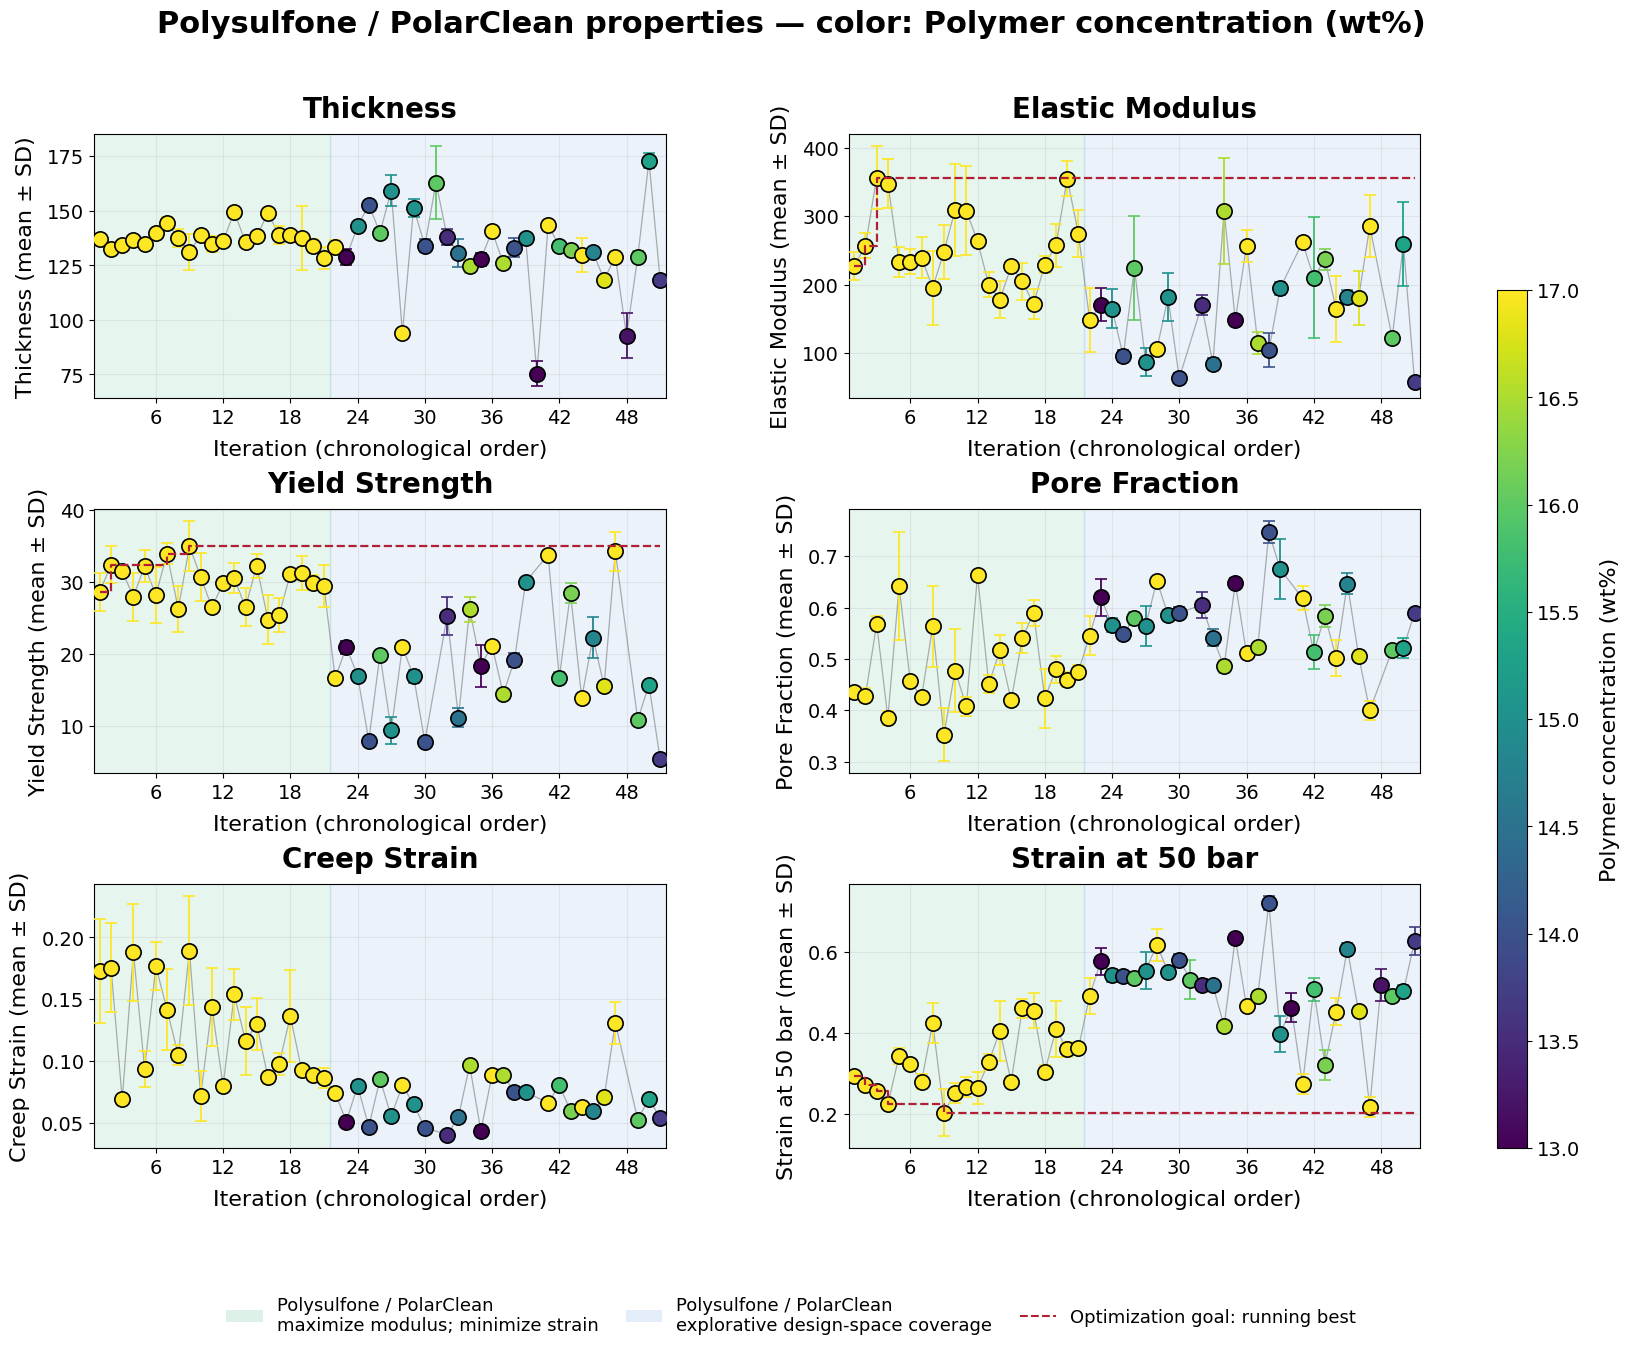

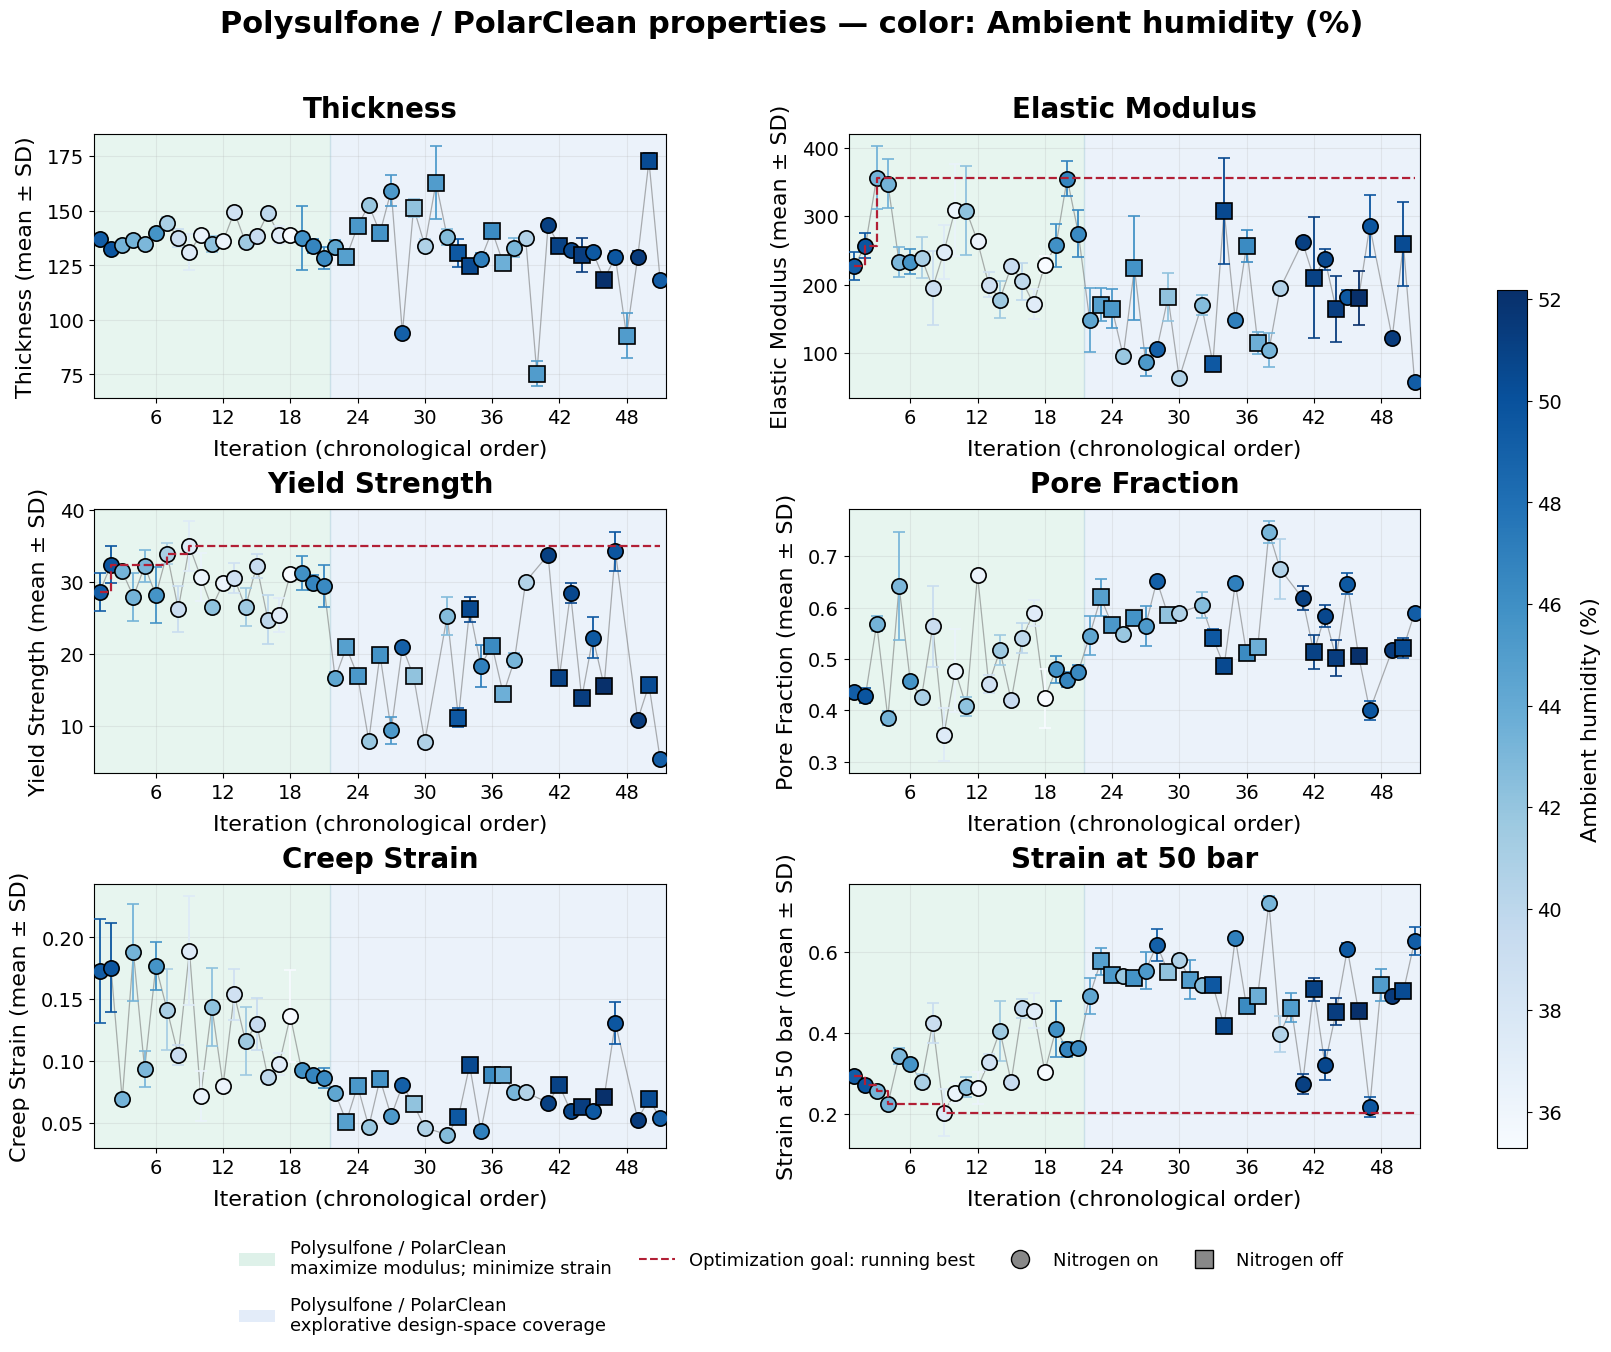

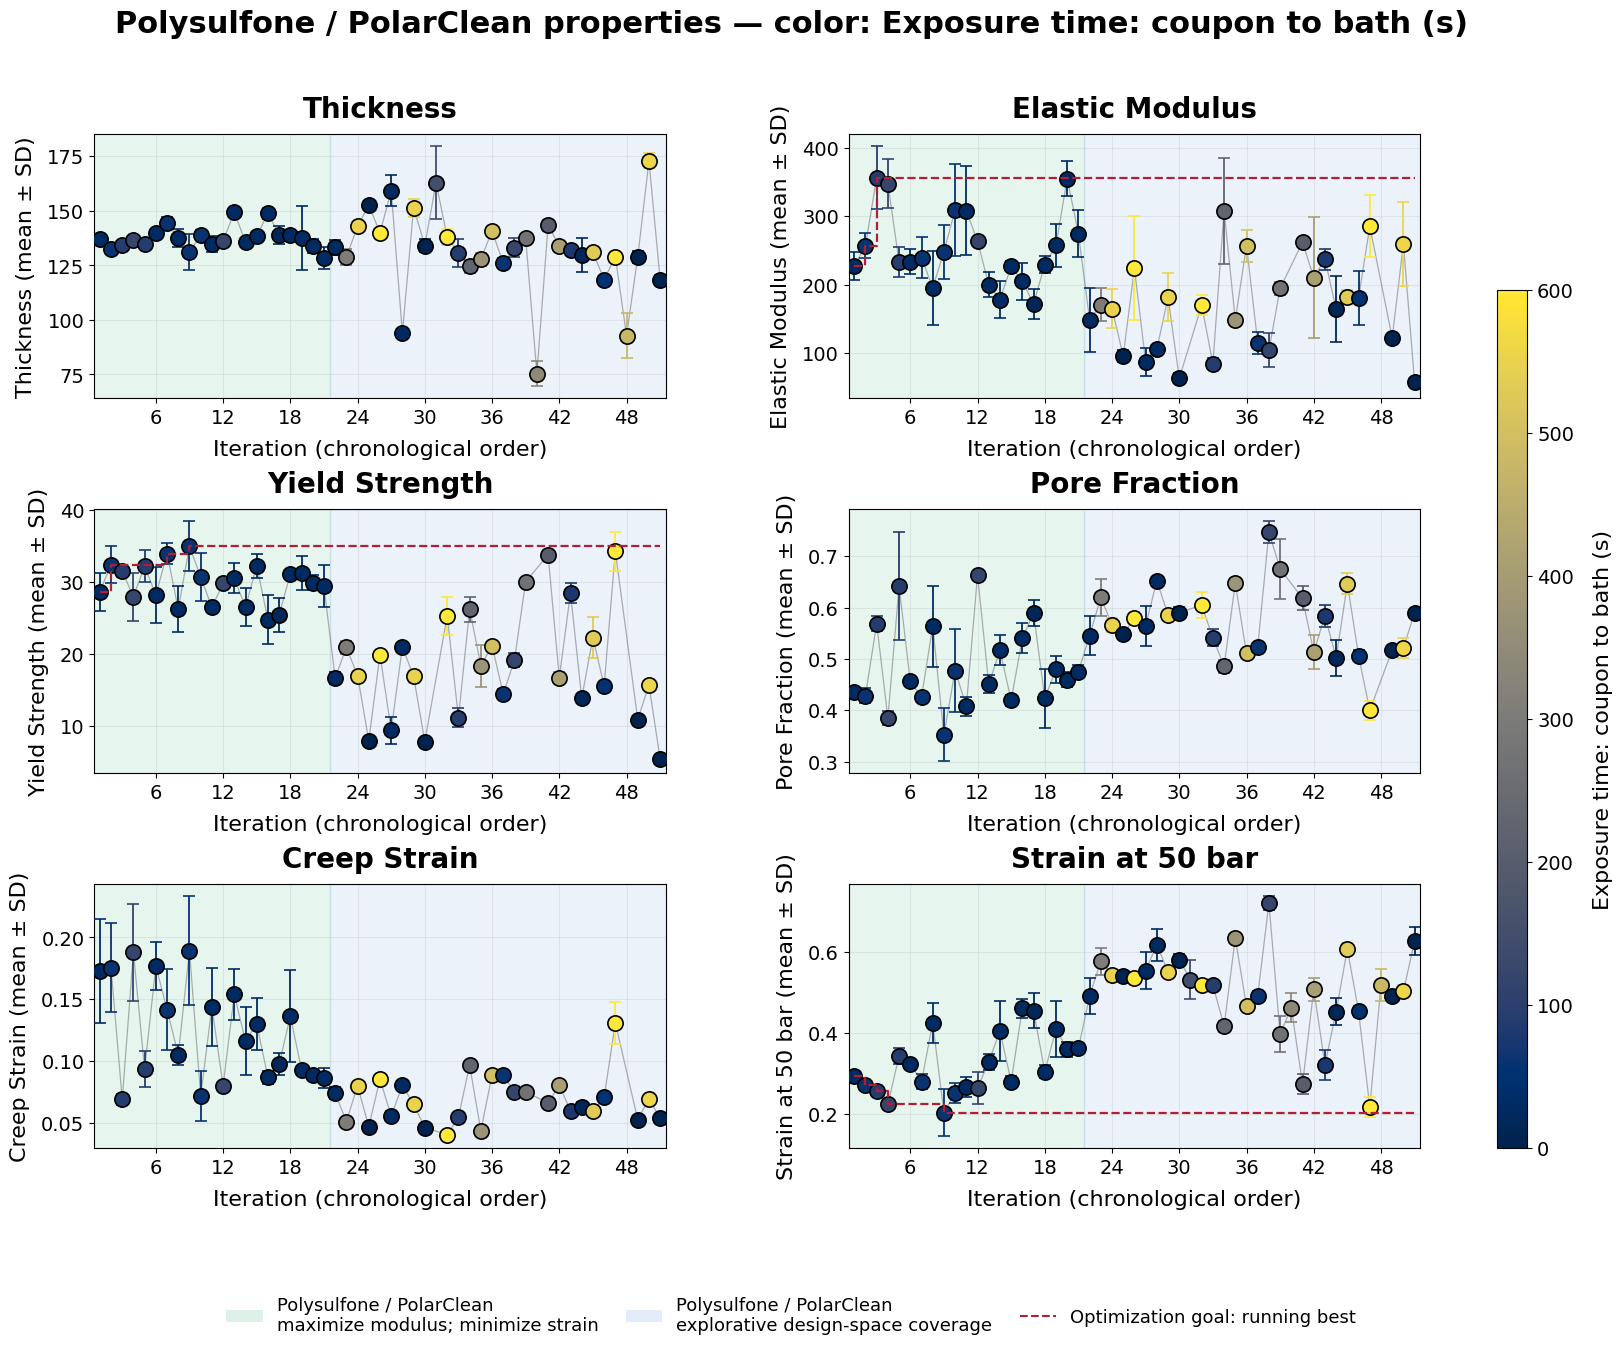

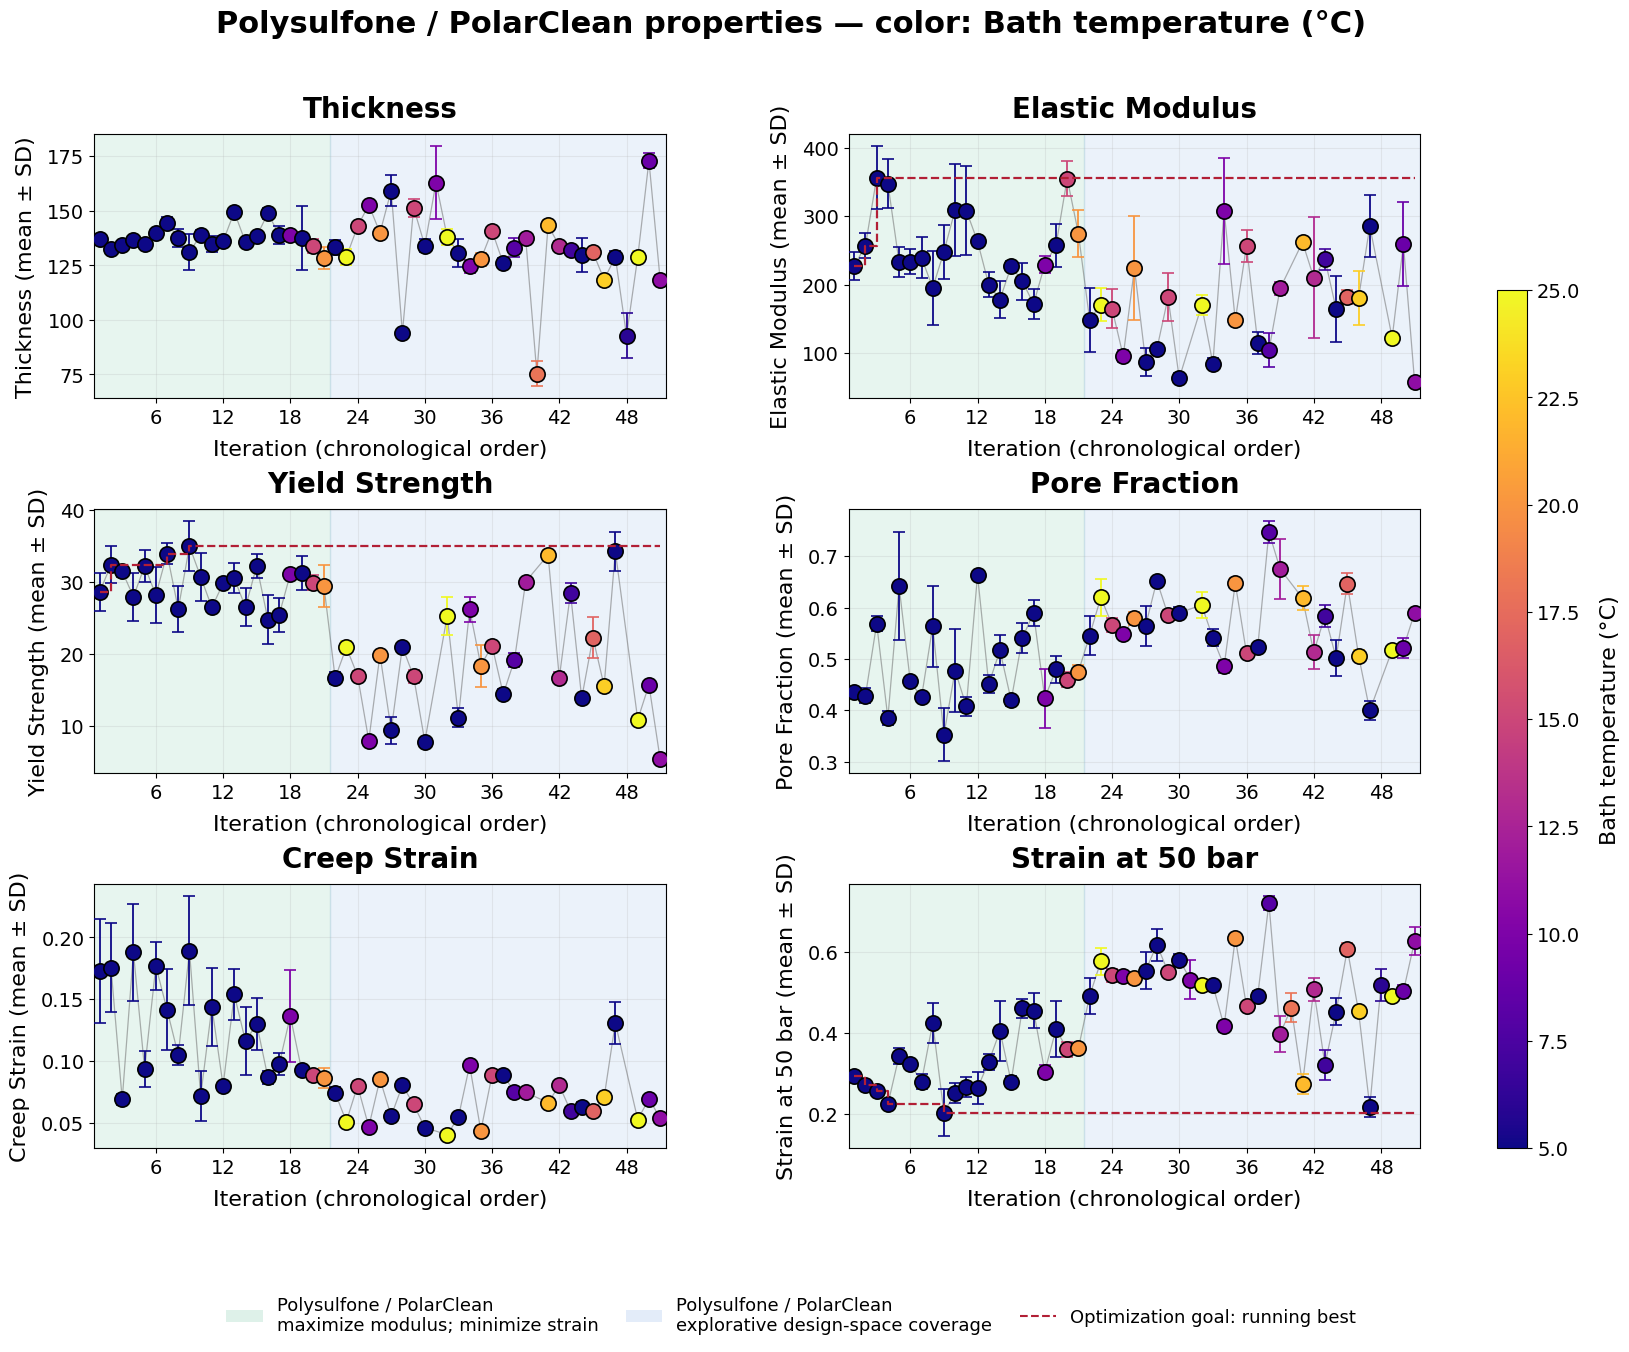

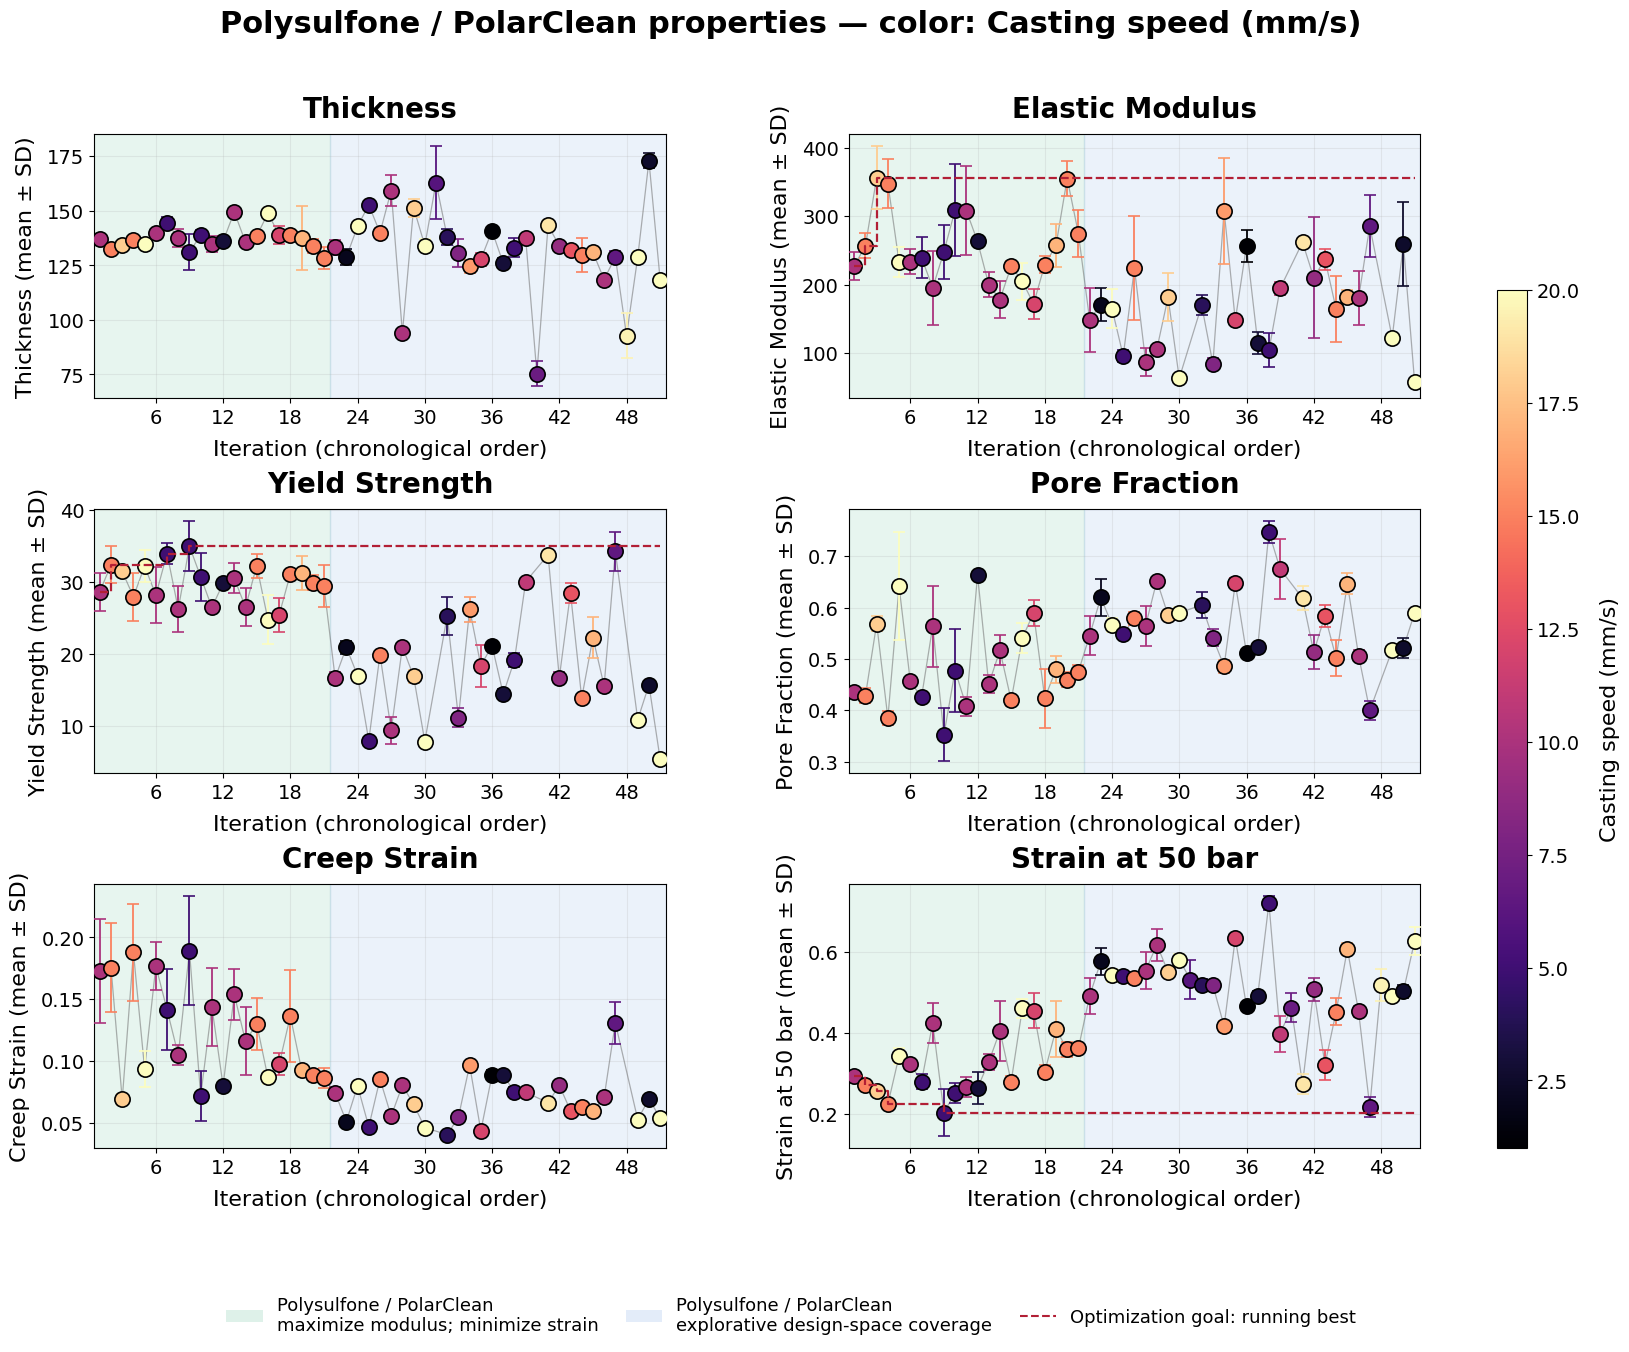

In [5]:
figure_polymer, axes_polymer, campaign_detailed = plot_detailed_campaign(
    campaign, PROPERTIES, 'polymer_wt', 'Polymer concentration (wt%)',
    connect_points=CONNECT_POINTS, cmap='viridis'
)
figure_humidity, axes_humidity, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'Humidity Mean', 'Ambient humidity (%)',
    nitrogen_markers=True, connect_points=CONNECT_POINTS, cmap='Blues'
)
figure_exposure, axes_exposure, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'coupon_to_bath_wait_time', 'Exposure time: coupon to bath (s)',
    connect_points=CONNECT_POINTS, cmap='cividis'
)
figure_bath, axes_bath, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'bath_temp', 'Bath temperature (°C)',
    connect_points=CONNECT_POINTS, cmap='plasma'
)
figure_casting, axes_casting, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'pullcast_speed', 'Casting speed (mm/s)',
    connect_points=CONNECT_POINTS, cmap='magma'
)
plt.show()

## Cross-validated feature importance

This section estimates which controllable and environmental variables are most useful for predicting each selected property. It uses a regularized linear (ridge) model with **repeated cross-validated permutation importance**. Importance is the increase in held-out mean absolute error (MAE) after shuffling one feature; larger positive values indicate greater predictive value.

Here, confidence means **stability across repeated train/test splits**, not a classical hypothesis-test confidence level. The table reports a 2.5th-to-97.5th percentile uncertainty interval across split repetitions, `probability_positive` (the fraction of repetitions with importance above zero), and `top_3_fraction` (how often the feature ranks among the three most important). A feature is `stable positive` only when its entire interval is above zero, `stable negative` when the interval is below zero, and `uncertain` otherwise.

The heatmap normalizes positive importances within each response so patterns can be compared across properties with different units. The detailed table retains raw mean importance and fold/repeat variability. With only about 31 samples, treat these rankings as exploratory associations—not causal effects. Correlated process settings may share or mask importance.

In [6]:
import numpy as np

FEATURES = {
    'polymer_wt': 'Polymer concentration',
    'mixing_temp': 'Mixing temperature',
    'bath_temp': 'Bath temperature',
    'pullcast_speed': 'Casting speed',
    'nitrogen': 'Nitrogen on/off',
    'nitrogen_exposure_time': 'Exposure time - N2 on',
    'air_exposure_time': 'Exposure time - N2 off',
    'nips_bath_wait_time': 'Bath residence time',
    'Humidity Mean': 'Ambient humidity',
}
MIN_TARGET_SAMPLES = 12
N_CV_REPEATS = 50
N_PERMUTATION_REPEATS = 10
RANDOM_STATE = 42
RIDGE_ALPHA = 1.0
FEATURE_IMPORTANCE_PROPERTIES = list(PROPERTIES) + ['CV']

def nitrogen_to_binary(value):
    """Convert CSV boolean/string nitrogen values without relying on another cell."""
    return 1 if (value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}) else 0

def cross_validated_permutation_importance(data, properties, features=FEATURES):
    records = []
    for property_name in properties:
        target_column = f'{property_name} Mean'
        usable = data.dropna(subset=[target_column]).copy()
        if len(usable) < MIN_TARGET_SAMPLES:
            print(f'Skipping {property_name}: only {len(usable)} usable samples')
            continue
        X = usable[list(features)].copy()
        X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
        X = X.apply(pd.to_numeric, errors='coerce')
        # Drop constants: they cannot have permutation importance in this subset.
        variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
        X = X[variable_columns]
        y = pd.to_numeric(usable[target_column], errors='coerce')
        splits = min(5, max(3, len(usable) // 5))
        repeat_importances = []
        for cv_repeat in range(N_CV_REPEATS):
            split_generator = np.random.RandomState(RANDOM_STATE + cv_repeat)
            shuffled_indices = split_generator.permutation(len(X))
            validation_folds = np.array_split(shuffled_indices, splits)
            weighted_sum = np.zeros(X.shape[1])
            held_out_count = 0
            for fold, test_index in enumerate(validation_folds, start=1):
                train_index = np.setdiff1d(shuffled_indices, test_index)
                X_train_frame, X_test_frame = X.iloc[train_index], X.iloc[test_index]
                medians = X_train_frame.median()
                X_train = X_train_frame.fillna(medians).to_numpy(dtype=float)
                X_test = X_test_frame.fillna(medians).to_numpy(dtype=float)
                center, scale = X_train.mean(axis=0), X_train.std(axis=0)
                scale[scale == 0] = 1
                X_train = (X_train - center) / scale
                X_test = (X_test - center) / scale
                y_train = y.iloc[train_index].to_numpy(dtype=float)
                y_test = y.iloc[test_index].to_numpy(dtype=float)
                y_center = y_train.mean()
                coefficients = np.linalg.solve(
                    X_train.T @ X_train + RIDGE_ALPHA * np.eye(X_train.shape[1]),
                    X_train.T @ (y_train - y_center),
                )
                baseline_error = np.mean(np.abs(y_test - (y_center + X_test @ coefficients)))
                fold_values = np.zeros((X.shape[1], N_PERMUTATION_REPEATS))
                fold_generator = np.random.RandomState(RANDOM_STATE + 1000 * cv_repeat + fold)
                for feature_index in range(X.shape[1]):
                    for permutation_repeat in range(N_PERMUTATION_REPEATS):
                        permuted = X_test.copy()
                        permuted[:, feature_index] = fold_generator.permutation(permuted[:, feature_index])
                        permuted_error = np.mean(np.abs(
                            y_test - (y_center + permuted @ coefficients)
                        ))
                        fold_values[feature_index, permutation_repeat] = permuted_error - baseline_error
                weighted_sum += fold_values.mean(axis=1) * len(test_index)
                held_out_count += len(test_index)
            repeat_importances.append(weighted_sum / held_out_count)
        repeat_importances = np.asarray(repeat_importances)
        repeat_ranks = np.argsort(np.argsort(-repeat_importances, axis=1), axis=1) + 1
        for feature_index, feature in enumerate(variable_columns):
            values = repeat_importances[:, feature_index]
            interval_low, interval_high = np.percentile(values, [2.5, 97.5])
            probability_positive = np.mean(values > 0)
            stability_label = ('stable positive' if interval_low > 0 else
                               'stable negative' if interval_high < 0 else 'uncertain')
            records.append({
                'property': property_name, 'feature': features[feature],
                'importance_mean': values.mean(),
                'importance_interval_low': interval_low,
                'importance_interval_high': interval_high,
                'probability_positive': probability_positive,
                'top_3_fraction': np.mean(repeat_ranks[:, feature_index] <= min(3, X.shape[1])),
                'stability': stability_label,
                'importance_sd_across_splits': values.std(ddof=1),
                'n_samples': len(usable), 'n_folds': splits, 'n_cv_repeats': N_CV_REPEATS,
            })
    return pd.DataFrame(records).sort_values(['property', 'importance_mean'], ascending=[True, False])

feature_importance = cross_validated_permutation_importance(
    campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES
)
feature_importance.head(20)

,property,feature,importance_mean,importance_interval_low,importance_interval_high,probability_positive,top_3_fraction,stability,importance_sd_across_splits,n_samples,n_folds,n_cv_repeats
54,CV,Polymer concentration,0.002016,0.000670,0.003299,1.00,0.90,stable positive,0.000735,46,5,50
56,CV,Bath temperature,0.001807,0.000785,0.002916,1.00,0.86,stable positive,0.000596,46,5,50
62,CV,Ambient humidity,0.001510,-0.000234,0.002614,0.96,0.68,uncertain,0.000810,46,5,50
59,CV,Exposure time - N2 on,0.001397,0.000212,0.002142,0.98,0.54,stable positive,0.000518,46,5,50
57,CV,Casting speed,-0.000048,-0.001306,0.001014,0.48,0.00,uncertain,0.000637,46,5,50
60,CV,Exposure time - N2 off,-0.000198,-0.001248,0.000521,0.34,0.00,uncertain,0.000457,46,5,50
58,CV,Nitrogen on/off,-0.000226,-0.001610,0.000928,0.36,0.02,uncertain,0.000651,46,5,50
61,CV,Bath residence time,-0.000490,-0.001425,0.000197,0.06,0.00,uncertain,0.000405,46,5,50
55,CV,Mixing temperature,-0.000578,-0.001654,0.000117,0.08,0.00,uncertain,0.000480,46,5,50
36,Creep Strain,Polymer concentration,0.009108,0.006741,0.011102,1.00,1.00,stable positive,0.001242,48,5,50


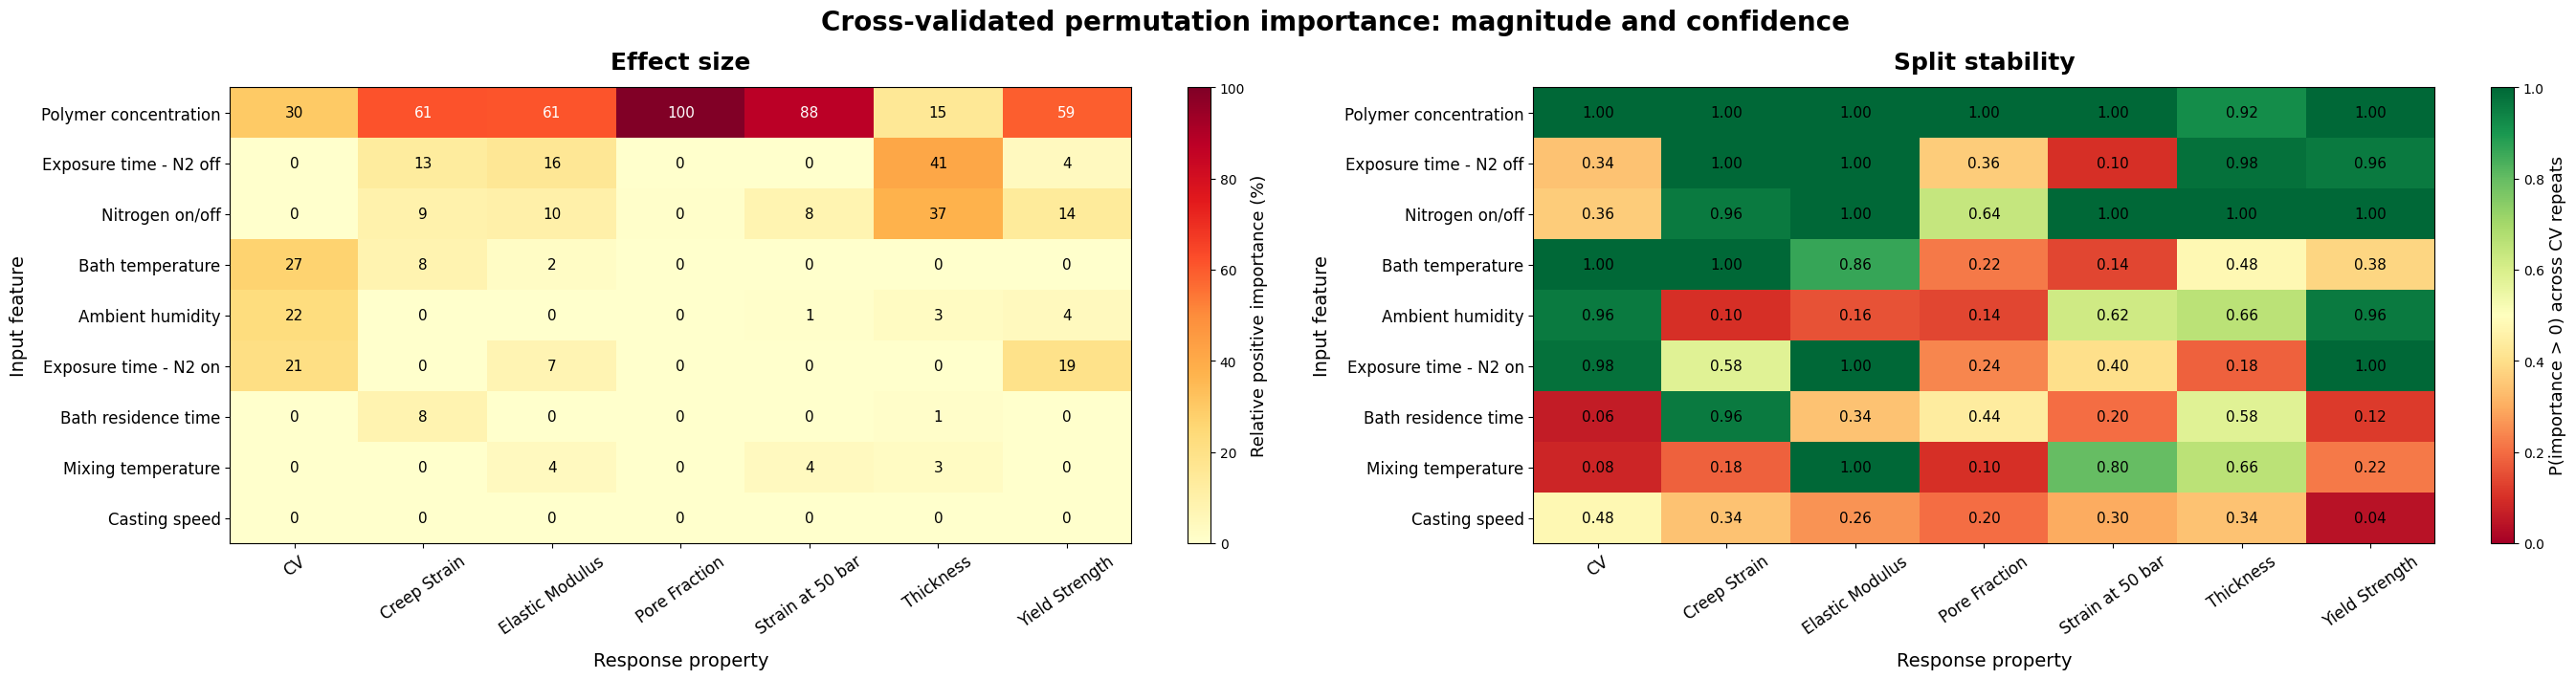

In [7]:
# Normalize positive importance within each property for a comparable 0–100% heatmap.
importance_for_plot = feature_importance.copy()
importance_for_plot['positive_importance'] = importance_for_plot['importance_mean'].clip(lower=0)
importance_for_plot['relative_importance'] = importance_for_plot.groupby('property')['positive_importance'].transform(
    lambda values: 100 * values / values.sum() if values.sum() > 0 else values
)
importance_matrix = importance_for_plot.pivot(index='feature', columns='property', values='relative_importance').fillna(0)
feature_order = importance_matrix.max(axis=1).sort_values(ascending=False).index
importance_matrix = importance_matrix.loc[feature_order]
confidence_matrix = importance_for_plot.pivot(index='feature', columns='property', values='probability_positive').fillna(0.5)
confidence_matrix = confidence_matrix.reindex(index=feature_order, columns=importance_matrix.columns)

figure_importance, (importance_axis, confidence_axis) = plt.subplots(
    1, 2, figsize=(max(18, 4.0 * len(importance_matrix.columns)), max(7, 0.8 * len(importance_matrix.index)))
)
heatmap = importance_axis.imshow(importance_matrix.to_numpy(), cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
confidence_heatmap = confidence_axis.imshow(confidence_matrix.to_numpy(), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for axis, matrix in [(importance_axis, importance_matrix), (confidence_axis, confidence_matrix)]:
    axis.set_xticks(range(len(matrix.columns)))
    axis.set_xticklabels(matrix.columns)
    axis.set_yticks(range(len(matrix.index)))
    axis.set_yticklabels(matrix.index)
    axis.tick_params(axis='x', labelsize=12, rotation=35)
    axis.tick_params(axis='y', labelsize=12)
for row_index in range(len(importance_matrix.index)):
    for column_index in range(len(importance_matrix.columns)):
        effect = importance_matrix.iloc[row_index, column_index]
        confidence = confidence_matrix.iloc[row_index, column_index]
        importance_axis.text(column_index, row_index, f'{effect:.0f}', ha='center', va='center',
                             fontsize=11, color='white' if effect > 55 else 'black')
        confidence_axis.text(column_index, row_index, f'{confidence:.2f}', ha='center', va='center', fontsize=11)
importance_colorbar = figure_importance.colorbar(heatmap, ax=importance_axis)
importance_colorbar.set_label('Relative positive importance (%)', fontsize=13)
confidence_colorbar = figure_importance.colorbar(confidence_heatmap, ax=confidence_axis)
confidence_colorbar.set_label('P(importance > 0) across CV repeats', fontsize=13)
importance_axis.set_title('Effect size', fontsize=18, fontweight='semibold', pad=14)
confidence_axis.set_title('Split stability', fontsize=18, fontweight='semibold', pad=14)
importance_axis.set_xlabel('Response property', fontsize=14, labelpad=10)
confidence_axis.set_xlabel('Response property', fontsize=14, labelpad=10)
importance_axis.set_ylabel('Input feature', fontsize=14, labelpad=10)
confidence_axis.set_ylabel('Input feature', fontsize=14, labelpad=10)
figure_importance.suptitle('Cross-validated permutation importance: magnitude and confidence', fontsize=20, fontweight='semibold')
figure_importance.tight_layout()
plt.show()

## Coupled nitrogen–exposure response surfaces

These panels use the same ridge specification to predict each property while varying nitrogen state and coupon-to-bath exposure time together. All other features are held at their median values. Black-edged points are the actual experiments. Because nitrogen is binary, only the **off** and **on** rows are physically observed; shading between them is visual interpolation, not an intermediate nitrogen setting.

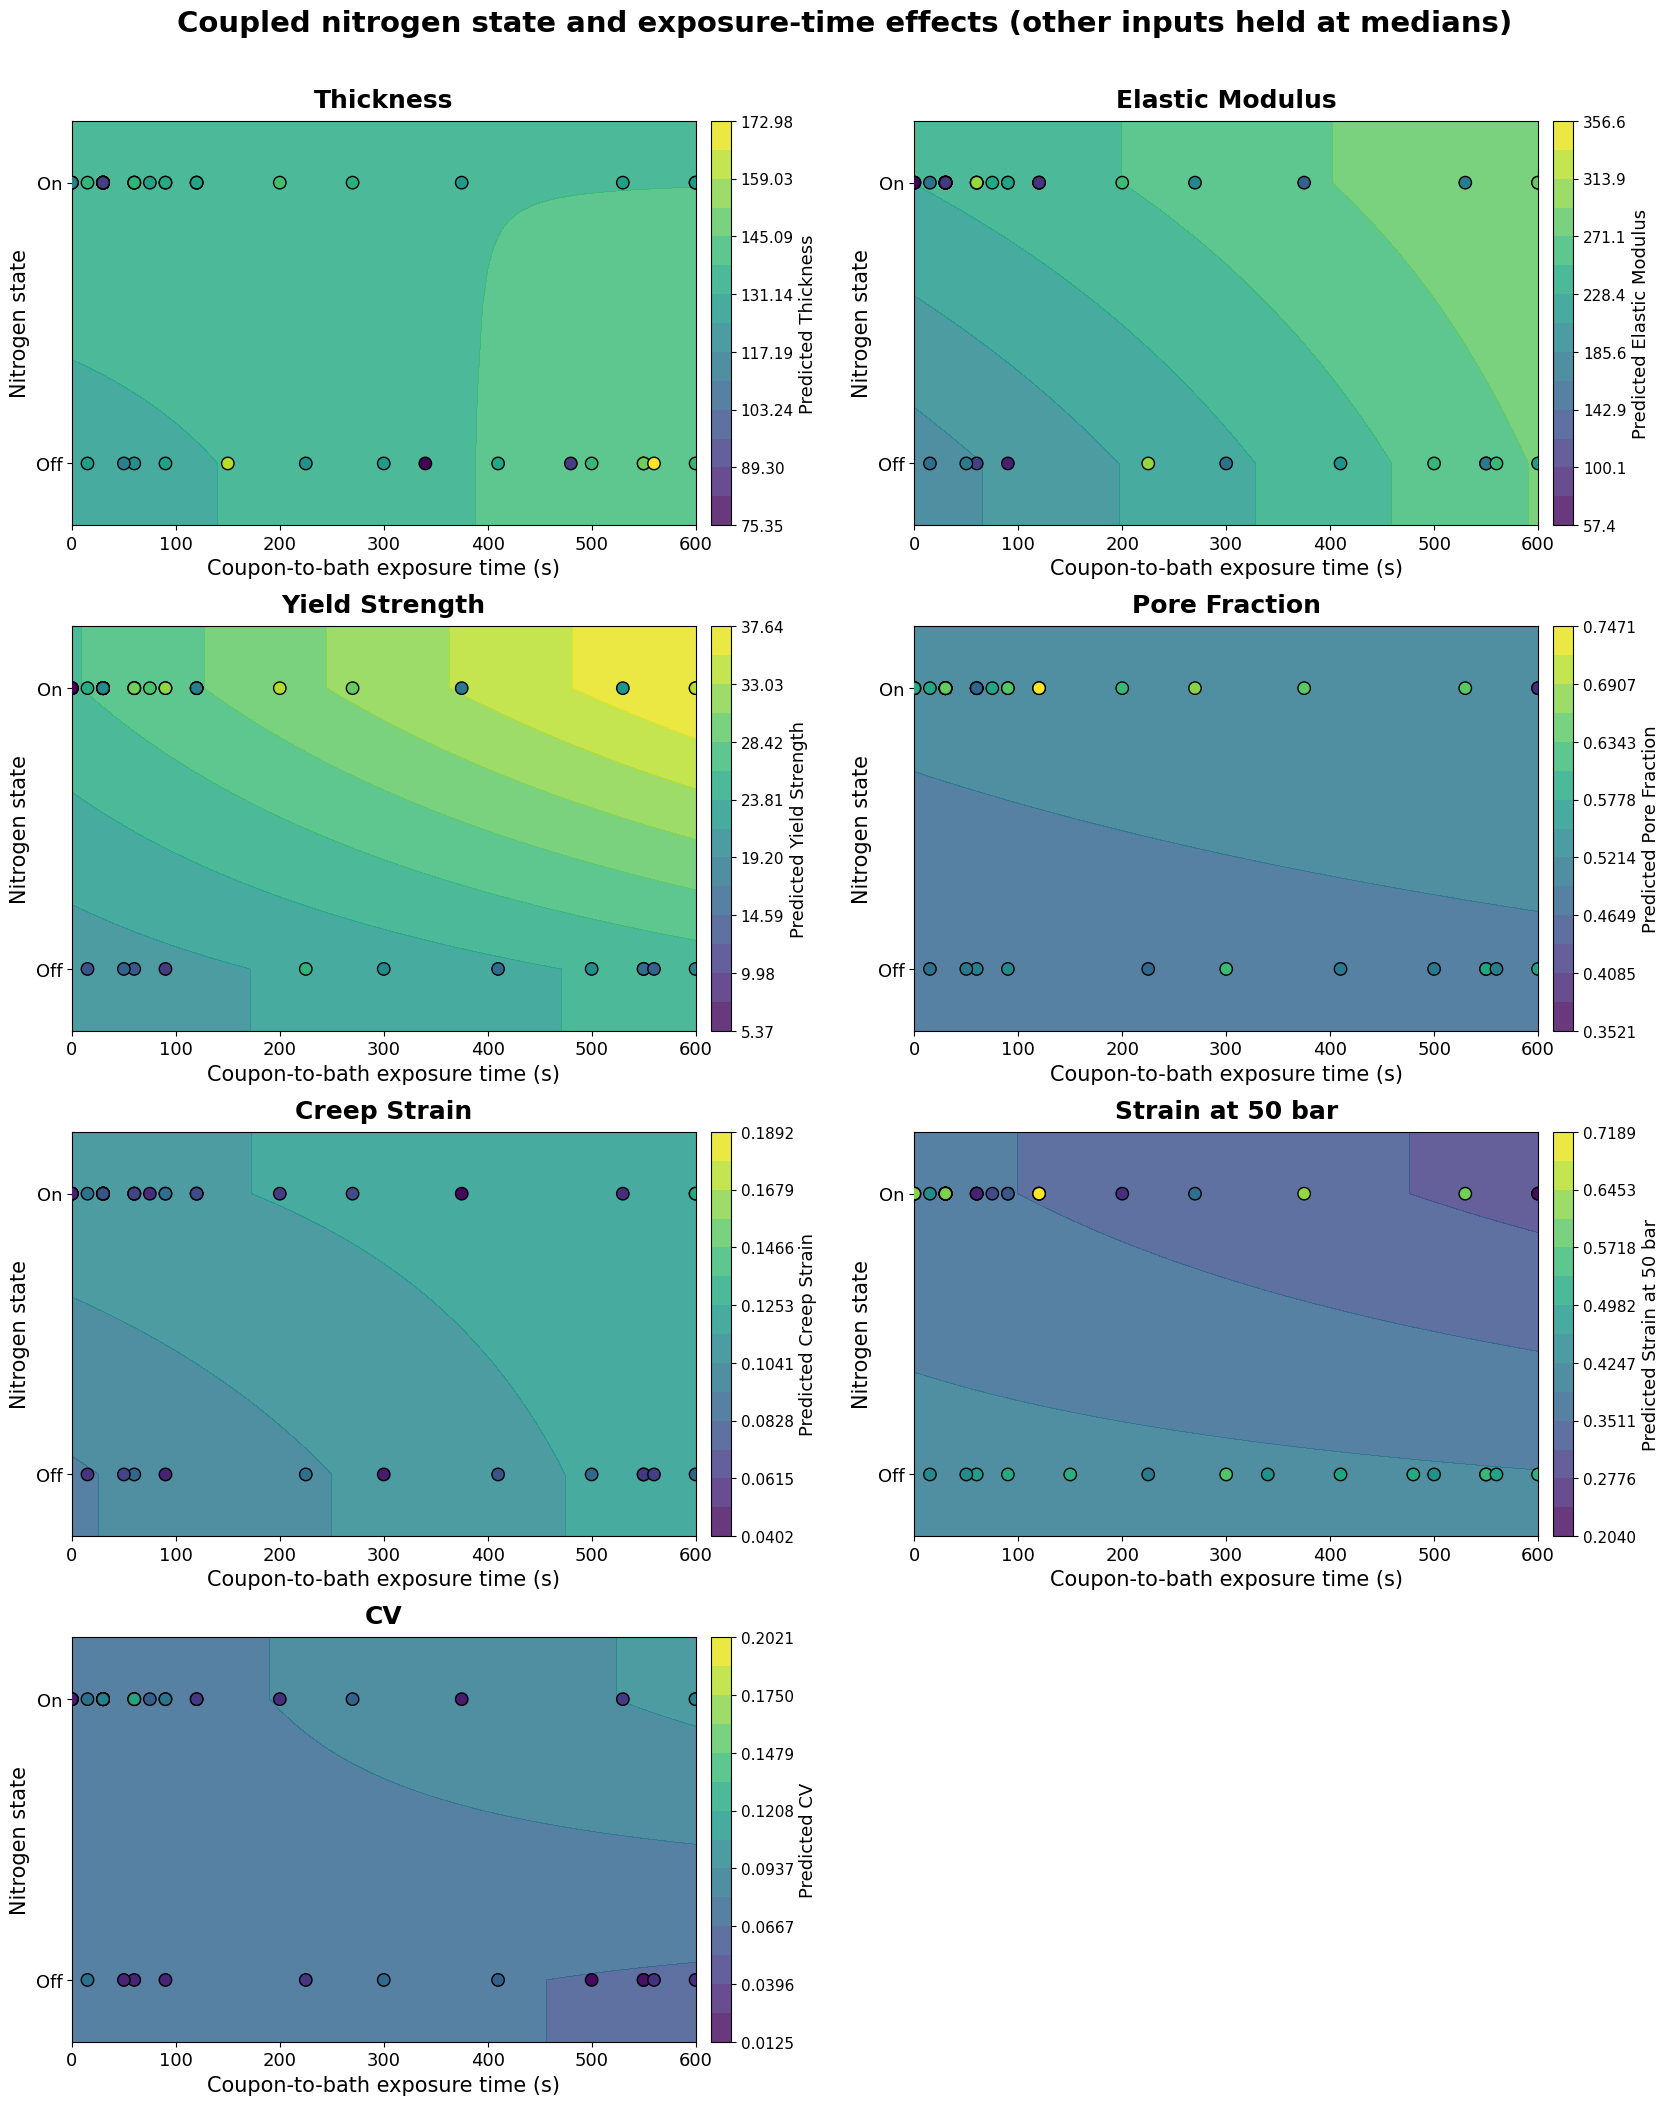

In [8]:
def fit_ridge_response_surface(data, property_name, features=FEATURES):
    target_column = f'{property_name} Mean'
    usable = data.dropna(subset=[target_column]).copy()
    X = usable[list(features)].copy()
    X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
    X = X.apply(pd.to_numeric, errors='coerce')
    variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
    X = X[variable_columns]
    medians = X.median()
    X_numeric = X.fillna(medians).to_numpy(dtype=float)
    center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
    scale[scale == 0] = 1
    X_standardized = (X_numeric - center) / scale
    y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
    baseline = y.mean()
    coefficients = np.linalg.solve(
        X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
        X_standardized.T @ (y - baseline),
    )
    exposure_grid = np.linspace(0, data['coupon_to_bath_wait_time'].max(), 121)
    surface_rows = []
    for nitrogen_state in (0, 1):
        grid = pd.DataFrame([medians.to_dict()] * len(exposure_grid))[variable_columns]
        if 'nitrogen' in grid:
            grid['nitrogen'] = nitrogen_state
        if 'nitrogen_exposure_time' in grid:
            grid['nitrogen_exposure_time'] = exposure_grid * nitrogen_state
        if 'air_exposure_time' in grid:
            grid['air_exposure_time'] = exposure_grid * (1 - nitrogen_state)
        grid_standardized = (grid.to_numpy(dtype=float) - center) / scale
        surface_rows.append(baseline + grid_standardized @ coefficients)
    return exposure_grid, np.vstack(surface_rows), usable

surface_properties = [prop for prop in FEATURE_IMPORTANCE_PROPERTIES
                      if campaign_detailed[f'{prop} Mean'].notna().sum() >= MIN_TARGET_SAMPLES]
surface_columns = 2
surface_rows = int(np.ceil(len(surface_properties) / surface_columns))
figure_nitrogen_exposure, surface_grid = plt.subplots(
    surface_rows, surface_columns, figsize=(17, 5.2 * surface_rows), squeeze=False
)
axes_nitrogen_exposure = list(surface_grid.flat)
for axis, property_name in zip(axes_nitrogen_exposure, surface_properties):
    exposure_grid, predicted_surface, observed = fit_ridge_response_surface(campaign_detailed, property_name)
    target_column = f'{property_name} Mean'
    value_min = min(predicted_surface.min(), observed[target_column].min())
    value_max = max(predicted_surface.max(), observed[target_column].max())
    levels = np.linspace(value_min, value_max, 15)
    # Duplicate the binary-state predictions into padded margins so observations
    # at 0 and 1 sit inside the colored field rather than on its outer edges.
    padded_states = [-0.22, 0, 1, 1.22]
    padded_surface = np.vstack([predicted_surface[0], predicted_surface[0],
                                predicted_surface[1], predicted_surface[1]])
    contour = axis.contourf(exposure_grid, padded_states, padded_surface, levels=levels, cmap='viridis', alpha=0.82)
    axis.scatter(observed['coupon_to_bath_wait_time'], observed['nitrogen_binary'],
                 c=observed[target_column], cmap='viridis', vmin=value_min, vmax=value_max,
                 s=80, edgecolor='black', linewidth=1.0, zorder=3)
    axis.set_title(property_name, fontsize=18, fontweight='semibold', pad=10)
    axis.set_xlabel('Coupon-to-bath exposure time (s)', fontsize=15)
    axis.set_ylabel('Nitrogen state', fontsize=15)
    axis.set_yticks([0, 1])
    axis.set_yticklabels(['Off', 'On'], fontsize=13)
    axis.set_ylim(-0.22, 1.22)
    axis.tick_params(axis='x', labelsize=13)
    property_colorbar = figure_nitrogen_exposure.colorbar(contour, ax=axis, pad=0.02)
    property_colorbar.set_label(f'Predicted {property_name}', fontsize=13)
    property_colorbar.ax.tick_params(labelsize=11)
for axis in axes_nitrogen_exposure[len(surface_properties):]:
    axis.remove()
figure_nitrogen_exposure.suptitle(
    'Coupled nitrogen state and exposure-time effects (other inputs held at medians)',
    fontsize=21, fontweight='semibold', y=1.01
)
figure_nitrogen_exposure.tight_layout()
plt.show()

## Ambient-humidity–exposure response surfaces

These panels vary ambient SHT40 humidity and coupon-to-bath exposure time while holding the remaining inputs at their medians. Predictions are averaged equally across a nitrogen-off prediction and a nitrogen-on prediction, so the surface represents a balanced nitrogen-marginalized response rather than assuming one nitrogen state. Actual experiments are overlaid as circles (N2 on) and squares (N2 off).

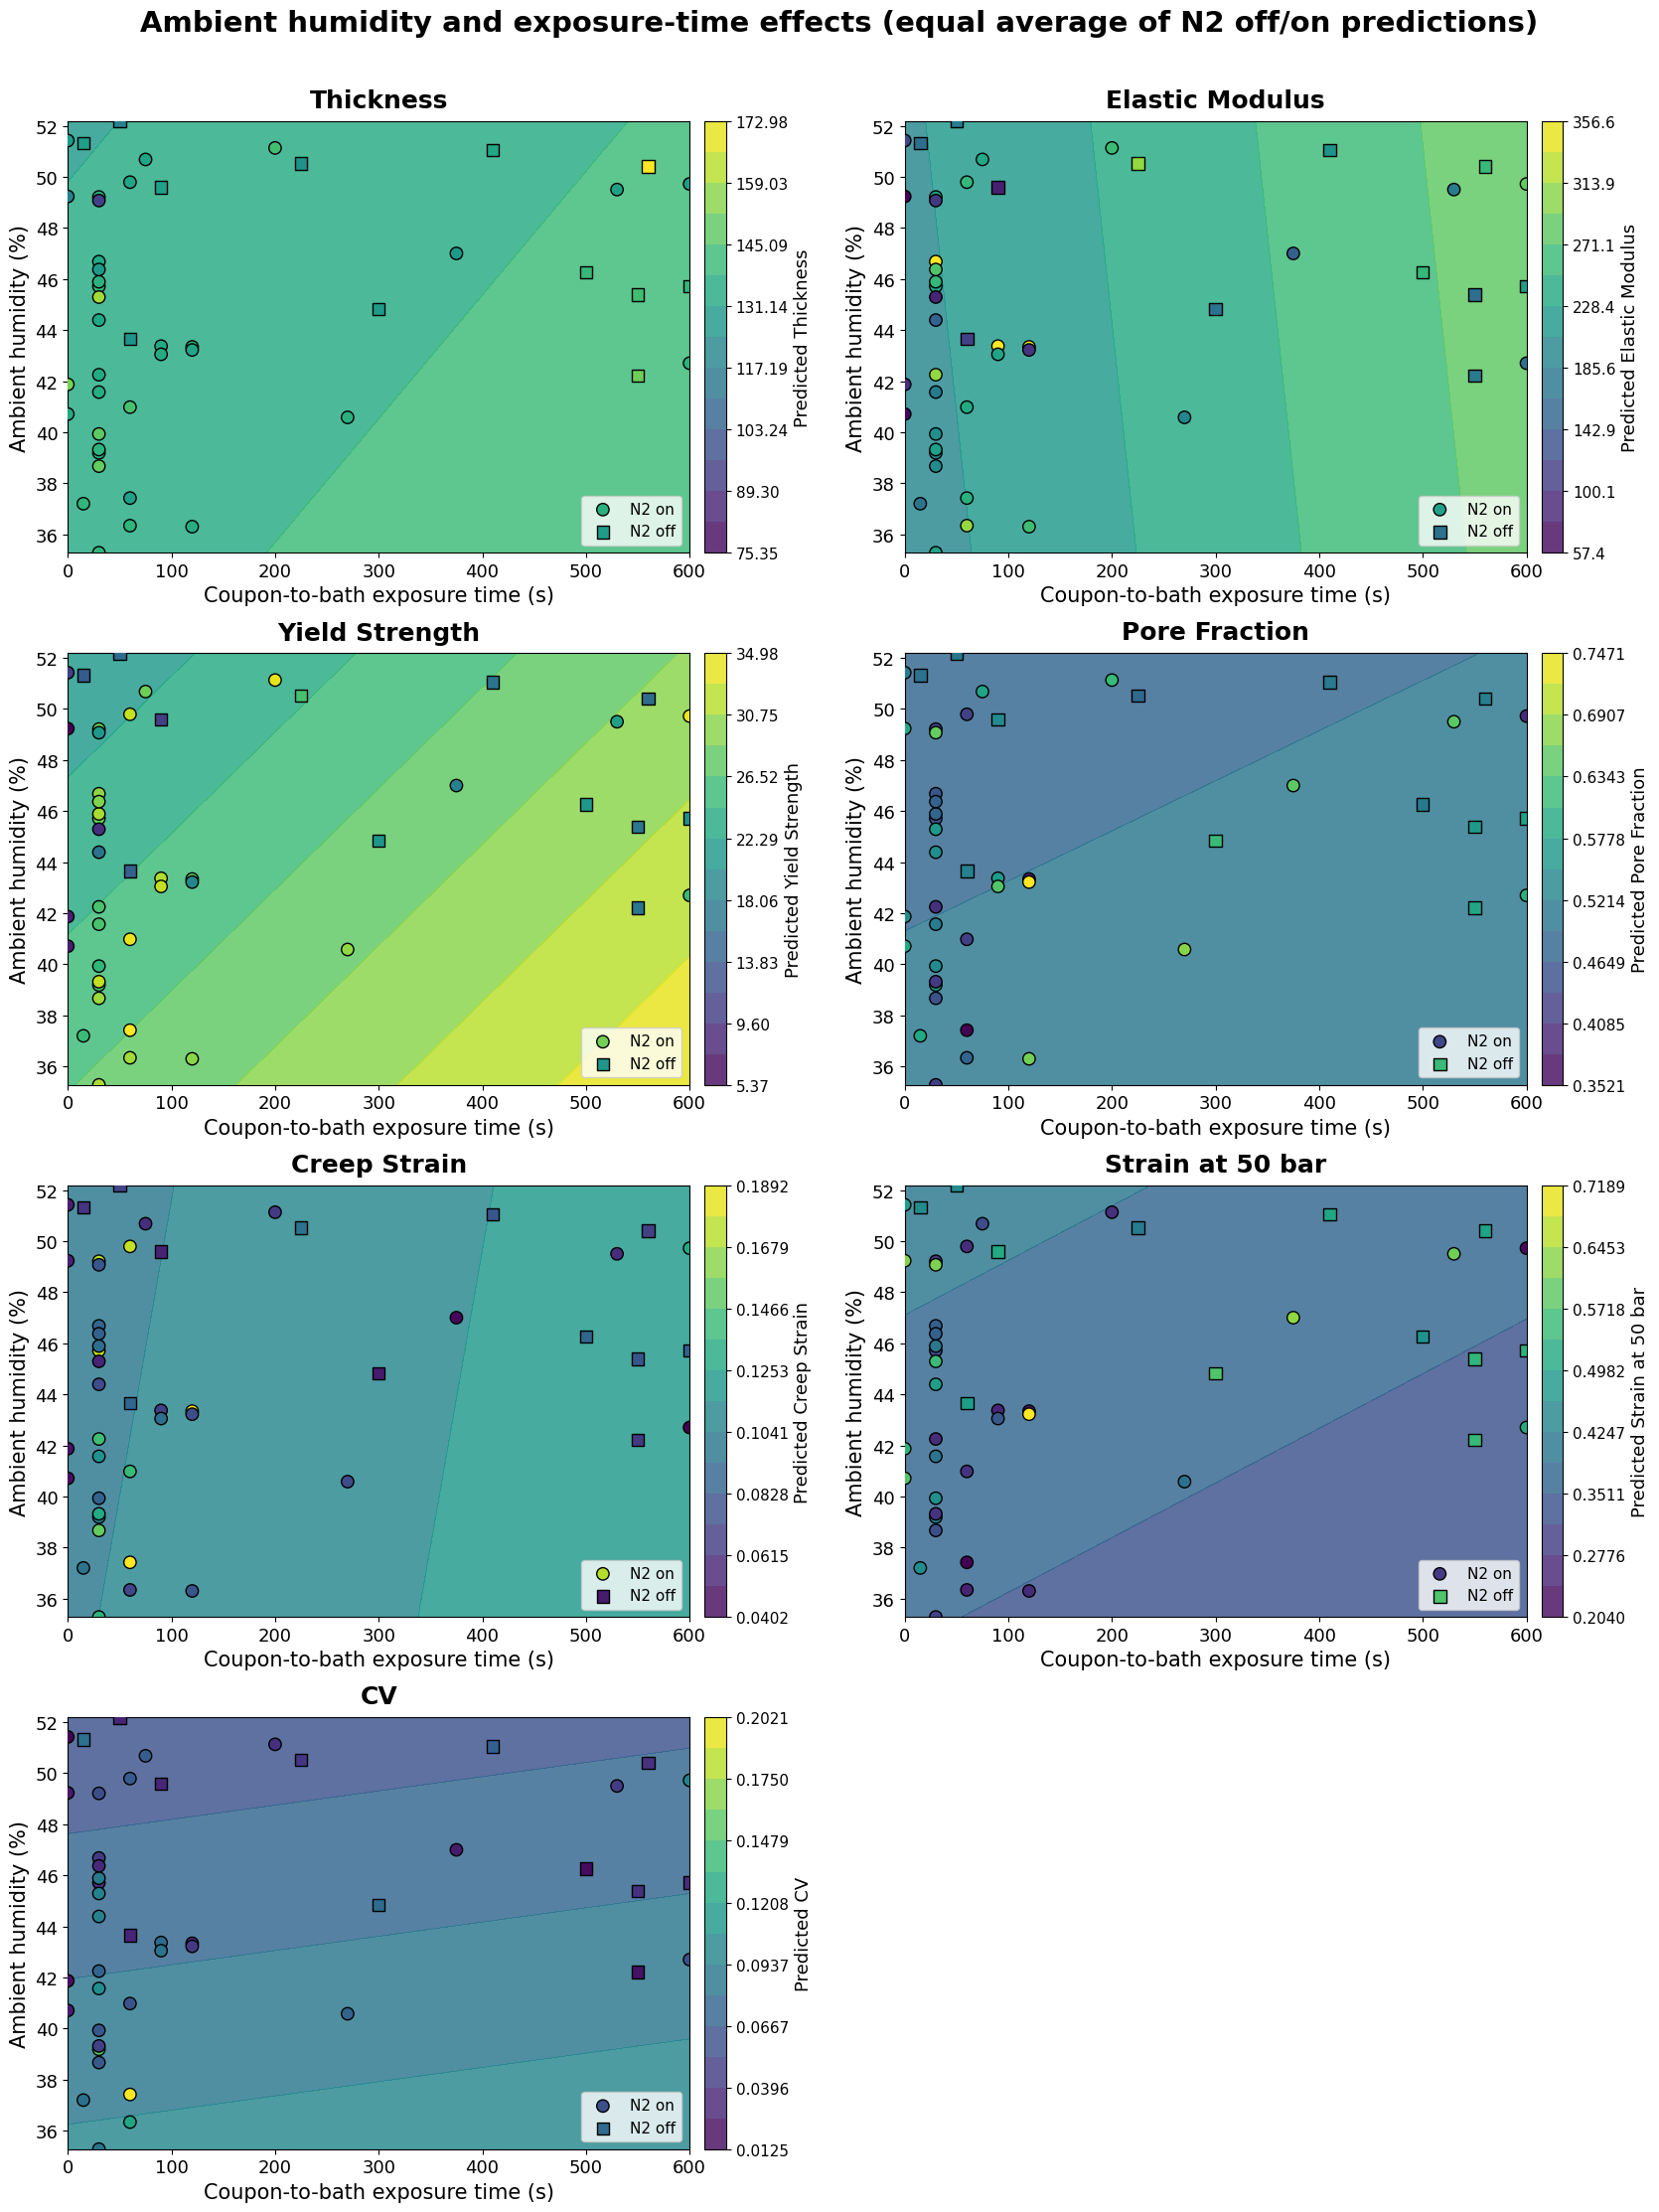

In [9]:
def fit_humidity_exposure_surface(data, property_name, features=FEATURES):
    target_column = f'{property_name} Mean'
    usable = data.dropna(subset=[target_column]).copy()
    X = usable[list(features)].copy()
    X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
    X = X.apply(pd.to_numeric, errors='coerce')
    variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
    X = X[variable_columns]
    medians = X.median()
    X_numeric = X.fillna(medians).to_numpy(dtype=float)
    center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
    scale[scale == 0] = 1
    X_standardized = (X_numeric - center) / scale
    y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
    baseline = y.mean()
    coefficients = np.linalg.solve(
        X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
        X_standardized.T @ (y - baseline),
    )
    humidity_observed = pd.to_numeric(data['Humidity Mean'], errors='coerce').dropna()
    humidity_grid = np.linspace(humidity_observed.min(), humidity_observed.max(), 80)
    exposure_grid = np.linspace(0, data['coupon_to_bath_wait_time'].max(), 100)
    exposure_mesh, humidity_mesh = np.meshgrid(exposure_grid, humidity_grid)
    state_predictions = []
    for nitrogen_state in (0, 1):
        grid = pd.DataFrame([medians.to_dict()] * exposure_mesh.size)[variable_columns]
        if 'Humidity Mean' in grid:
            grid['Humidity Mean'] = humidity_mesh.ravel()
        if 'nitrogen' in grid:
            grid['nitrogen'] = nitrogen_state
        if 'nitrogen_exposure_time' in grid:
            grid['nitrogen_exposure_time'] = exposure_mesh.ravel() * nitrogen_state
        if 'air_exposure_time' in grid:
            grid['air_exposure_time'] = exposure_mesh.ravel() * (1 - nitrogen_state)
        grid_standardized = (grid.to_numpy(dtype=float) - center) / scale
        state_predictions.append((baseline + grid_standardized @ coefficients).reshape(humidity_mesh.shape))
    marginalized_surface = np.mean(state_predictions, axis=0)
    return exposure_mesh, humidity_mesh, marginalized_surface, usable

figure_humidity_exposure, humidity_surface_grid = plt.subplots(
    surface_rows, surface_columns, figsize=(17, 5.5 * surface_rows), squeeze=False
)
axes_humidity_exposure = list(humidity_surface_grid.flat)
for axis, property_name in zip(axes_humidity_exposure, surface_properties):
    exposure_mesh, humidity_mesh, predicted_surface, observed = fit_humidity_exposure_surface(
        campaign_detailed, property_name
    )
    target_column = f'{property_name} Mean'
    value_min = min(predicted_surface.min(), observed[target_column].min())
    value_max = max(predicted_surface.max(), observed[target_column].max())
    levels = np.linspace(value_min, value_max, 15)
    contour = axis.contourf(exposure_mesh, humidity_mesh, predicted_surface,
                            levels=levels, cmap='viridis', alpha=0.82)
    for nitrogen_state, marker, label in [(1, 'o', 'N2 on'), (0, 's', 'N2 off')]:
        state_points = observed[observed['nitrogen_binary'] == nitrogen_state]
        axis.scatter(state_points['coupon_to_bath_wait_time'], state_points['Humidity Mean'],
                     c=state_points[target_column], cmap='viridis', vmin=value_min, vmax=value_max,
                     marker=marker, s=80, edgecolor='black', linewidth=1.0, label=label, zorder=3)
    axis.set_title(property_name, fontsize=18, fontweight='semibold', pad=10)
    axis.set_xlabel('Coupon-to-bath exposure time (s)', fontsize=15)
    axis.set_ylabel('Ambient humidity (%)', fontsize=15)
    axis.tick_params(labelsize=13)
    axis.legend(fontsize=11, loc='best', frameon=True)
    property_colorbar = figure_humidity_exposure.colorbar(contour, ax=axis, pad=0.02)
    property_colorbar.set_label(f'Predicted {property_name}', fontsize=13)
    property_colorbar.ax.tick_params(labelsize=11)
for axis in axes_humidity_exposure[len(surface_properties):]:
    axis.remove()
figure_humidity_exposure.suptitle(
    'Ambient humidity and exposure-time effects (equal average of N2 off/on predictions)',
    fontsize=21, fontweight='semibold', y=1.01
)
figure_humidity_exposure.tight_layout()
plt.show()

## Linear SHAP analysis

For the standardized ridge model, the SHAP contribution under a mean-background/feature-independence assumption is `(standardized feature value) × (ridge coefficient)`. The contributions are additive: their sum plus the baseline prediction equals the model prediction. Positive values push a predicted property upward; negative values push it downward.

The first figure summarizes global mean absolute SHAP magnitude. It is followed by a signed per-iteration contribution plot for every modeled response; point color indicates the original feature value. These are model explanations, not causal effects. Correlated campaign settings can redistribute attribution among features.

In [10]:
def calculate_linear_shap(data, properties, features=FEATURES):
    shap_records = []
    prediction_records = []
    for property_name in properties:
        target_column = f'{property_name} Mean'
        usable = data.dropna(subset=[target_column]).copy()
        if len(usable) < MIN_TARGET_SAMPLES:
            continue
        X = usable[list(features)].copy()
        X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
        X = X.apply(pd.to_numeric, errors='coerce')
        variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
        X = X[variable_columns]
        medians = X.median()
        X_numeric = X.fillna(medians).to_numpy(dtype=float)
        center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
        scale[scale == 0] = 1
        X_standardized = (X_numeric - center) / scale
        y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
        baseline = y.mean()
        coefficients = np.linalg.solve(
            X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
            X_standardized.T @ (y - baseline),
        )
        shap_values = X_standardized * coefficients
        predictions = baseline + shap_values.sum(axis=1)
        for row_position, (_, sample) in enumerate(usable.iterrows()):
            prediction_records.append({
                'property': property_name, 'iteration': sample['iteration'],
                'observed': y[row_position], 'prediction': predictions[row_position],
                'baseline': baseline,
            })
            for feature_position, feature in enumerate(variable_columns):
                shap_records.append({
                    'property': property_name, 'iteration': sample['iteration'],
                    'feature': features[feature], 'feature_column': feature,
                    'feature_value': X_numeric[row_position, feature_position],
                    'shap_value': shap_values[row_position, feature_position],
                })
    return pd.DataFrame(shap_records), pd.DataFrame(prediction_records)

shap_values, shap_predictions = calculate_linear_shap(
    campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES
)
# Numerical check of the additive SHAP identity.
assert np.allclose(
    shap_predictions['prediction'],
    shap_predictions['baseline'] + shap_values.groupby(['property', 'iteration'])['shap_value'].sum().reindex(
        pd.MultiIndex.from_frame(shap_predictions[['property', 'iteration']])
    ).to_numpy(),
)
shap_values.head()

,property,iteration,feature,feature_column,feature_value,shap_value
0,Thickness,1,Polymer concentration,polymer_wt,17.0,3.627260
1,Thickness,1,Mixing temperature,mixing_temp,25.0,-2.280126
2,Thickness,1,Bath temperature,bath_temp,5.0,-0.475543
3,Thickness,1,Casting speed,pullcast_speed,10.0,0.624802
4,Thickness,1,Nitrogen on/off,nitrogen,1.0,3.137923


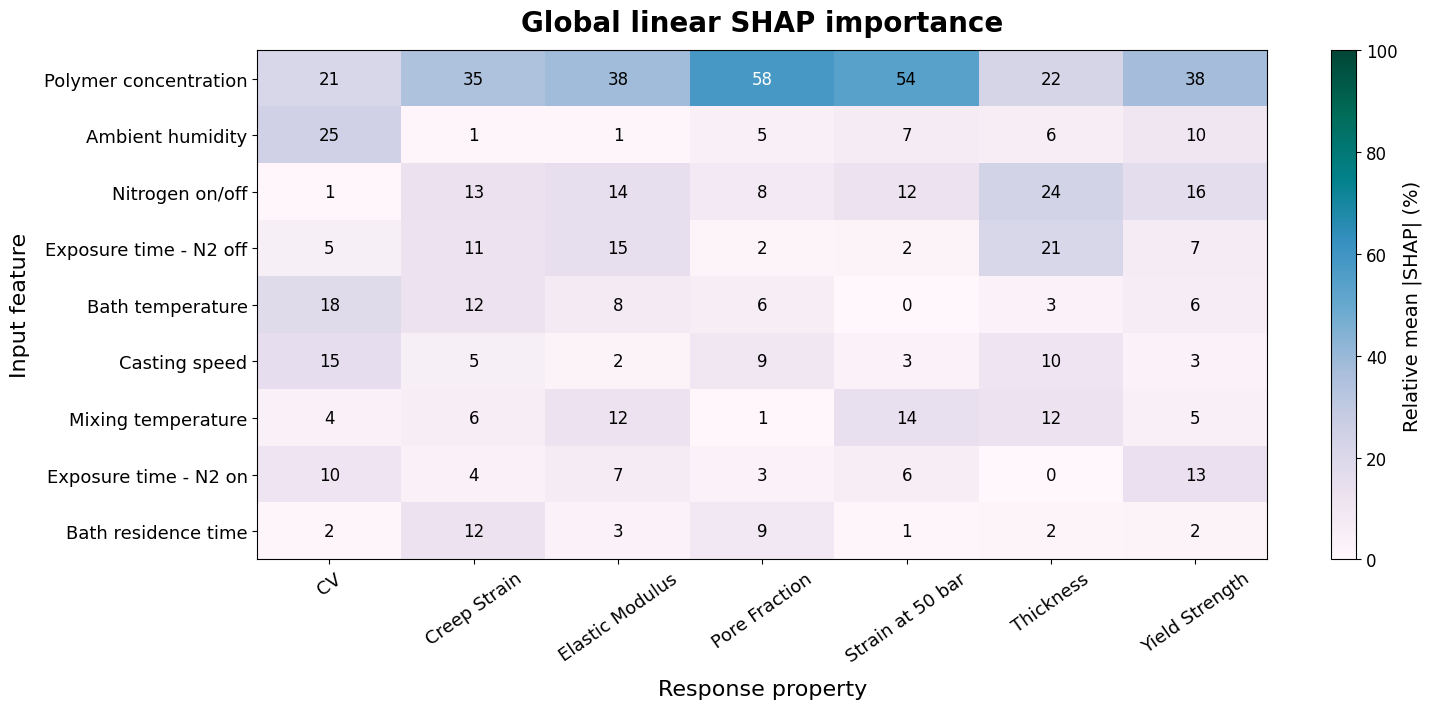

In [11]:
global_shap = (shap_values.assign(abs_shap=lambda frame: frame['shap_value'].abs())
               .groupby(['feature', 'property'], as_index=False)['abs_shap'].mean())
global_shap['relative_mean_abs_shap'] = global_shap.groupby('property')['abs_shap'].transform(
    lambda values: 100 * values / values.sum() if values.sum() > 0 else values
)
shap_matrix = global_shap.pivot(index='feature', columns='property', values='relative_mean_abs_shap').fillna(0)
shap_matrix = shap_matrix.loc[shap_matrix.max(axis=1).sort_values(ascending=False).index]

figure_shap_global, shap_global_axis = plt.subplots(
    figsize=(max(12, 2.2 * len(shap_matrix.columns)), max(7, 0.8 * len(shap_matrix.index)))
)
shap_image = shap_global_axis.imshow(shap_matrix.to_numpy(), cmap='PuBuGn', vmin=0, vmax=100, aspect='auto')
shap_global_axis.set_xticks(range(len(shap_matrix.columns)))
shap_global_axis.set_xticklabels(shap_matrix.columns)
shap_global_axis.set_yticks(range(len(shap_matrix.index)))
shap_global_axis.set_yticklabels(shap_matrix.index)
for row_index in range(len(shap_matrix.index)):
    for column_index in range(len(shap_matrix.columns)):
        value = shap_matrix.iloc[row_index, column_index]
        shap_global_axis.text(column_index, row_index, f'{value:.0f}', ha='center', va='center',
                              fontsize=12, color='white' if value > 55 else 'black')
shap_global_colorbar = figure_shap_global.colorbar(shap_image, ax=shap_global_axis)
shap_global_colorbar.set_label('Relative mean |SHAP| (%)', fontsize=14)
shap_global_colorbar.ax.tick_params(labelsize=12)
shap_global_axis.set_title('Global linear SHAP importance', fontsize=20, fontweight='semibold', pad=14)
shap_global_axis.set_xlabel('Response property', fontsize=16, labelpad=10)
shap_global_axis.set_ylabel('Input feature', fontsize=16, labelpad=10)
shap_global_axis.tick_params(axis='x', labelsize=13, rotation=35)
shap_global_axis.tick_params(axis='y', labelsize=13)
figure_shap_global.tight_layout()
plt.show()

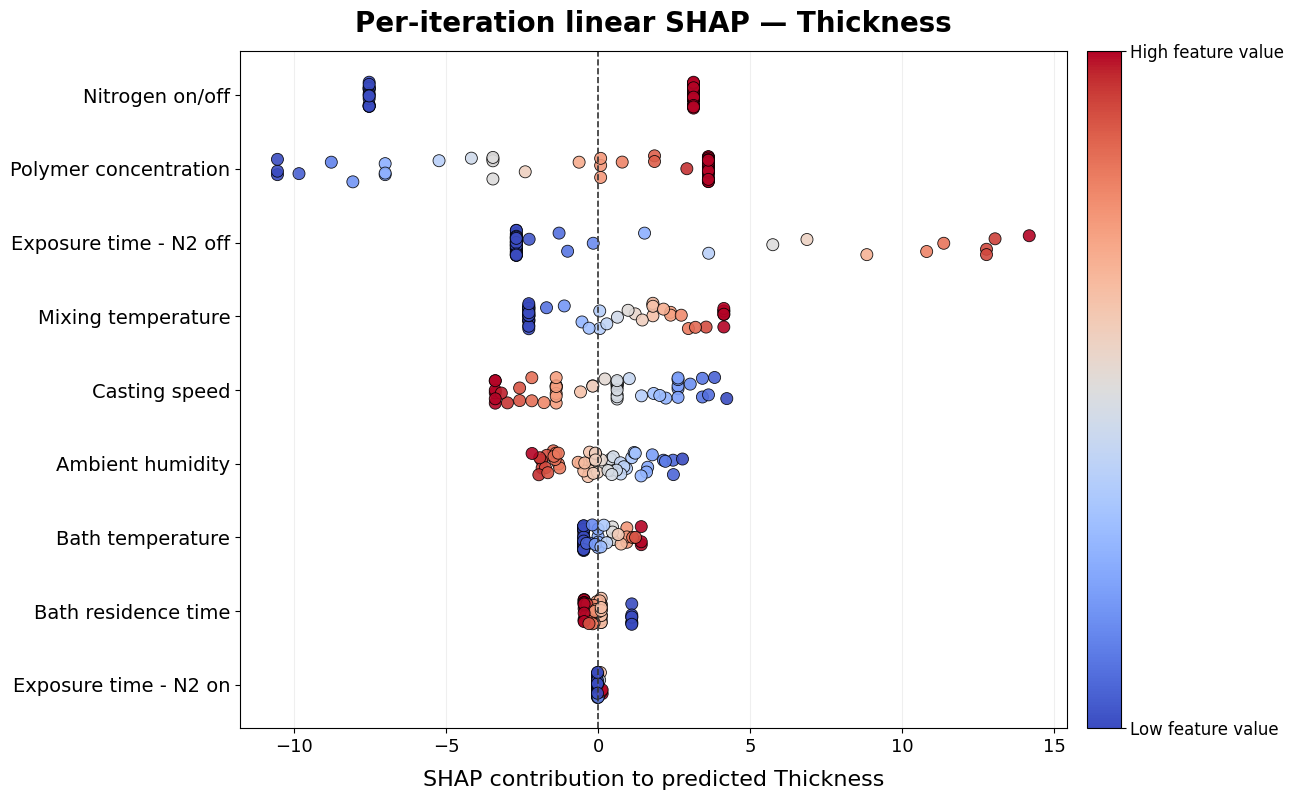

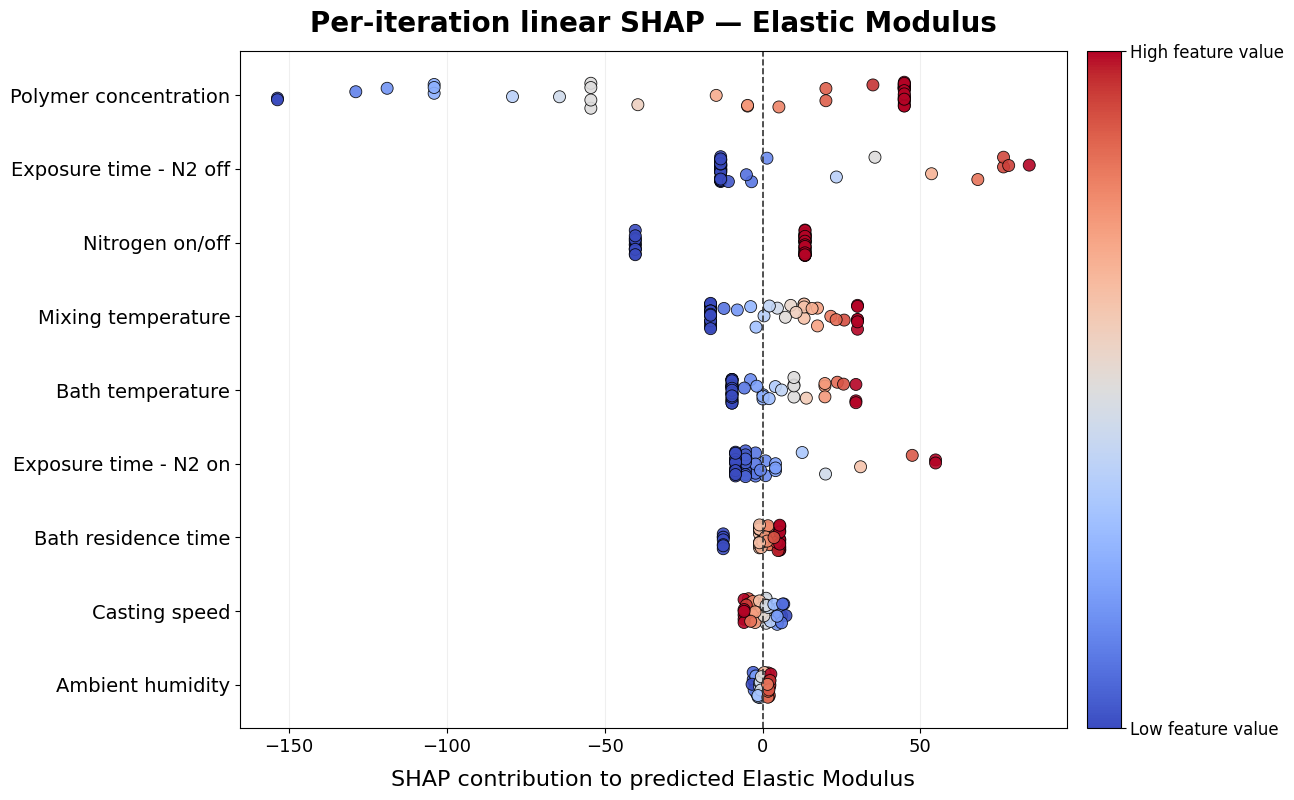

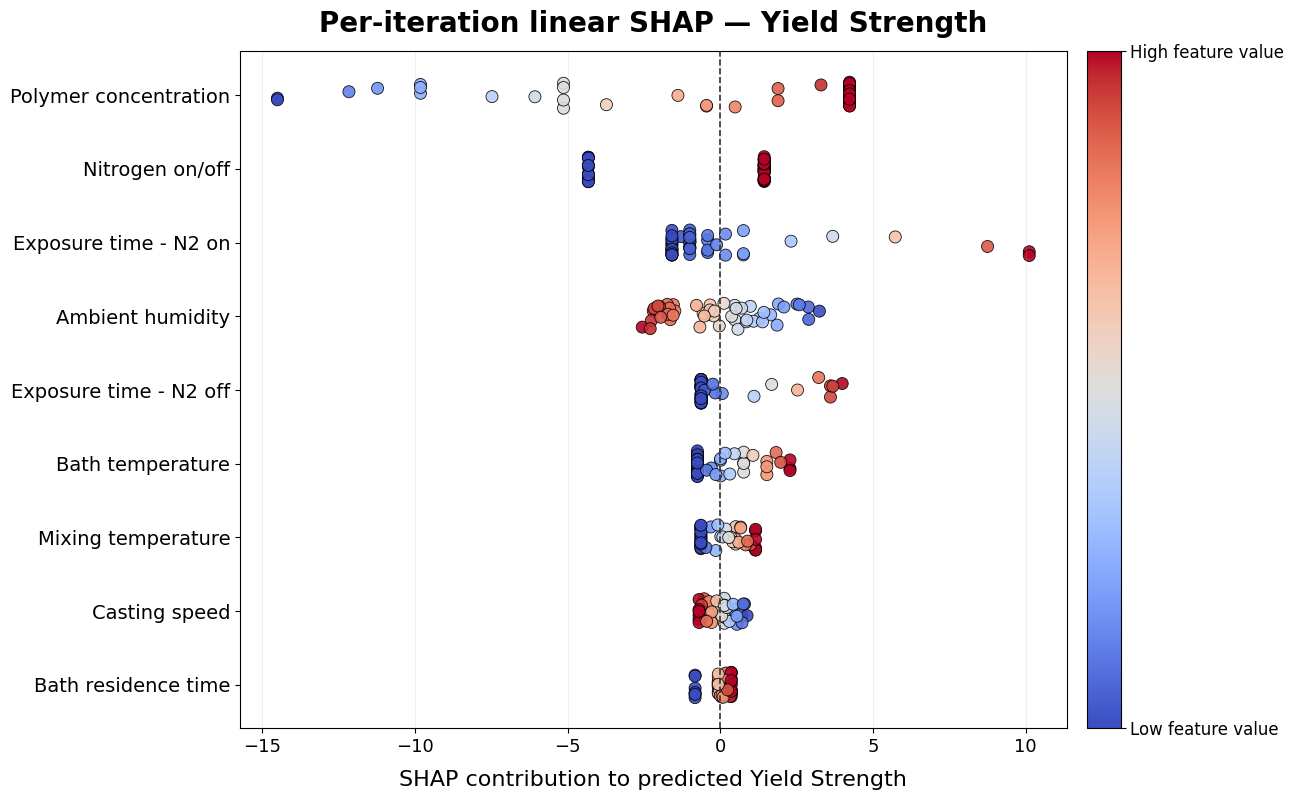

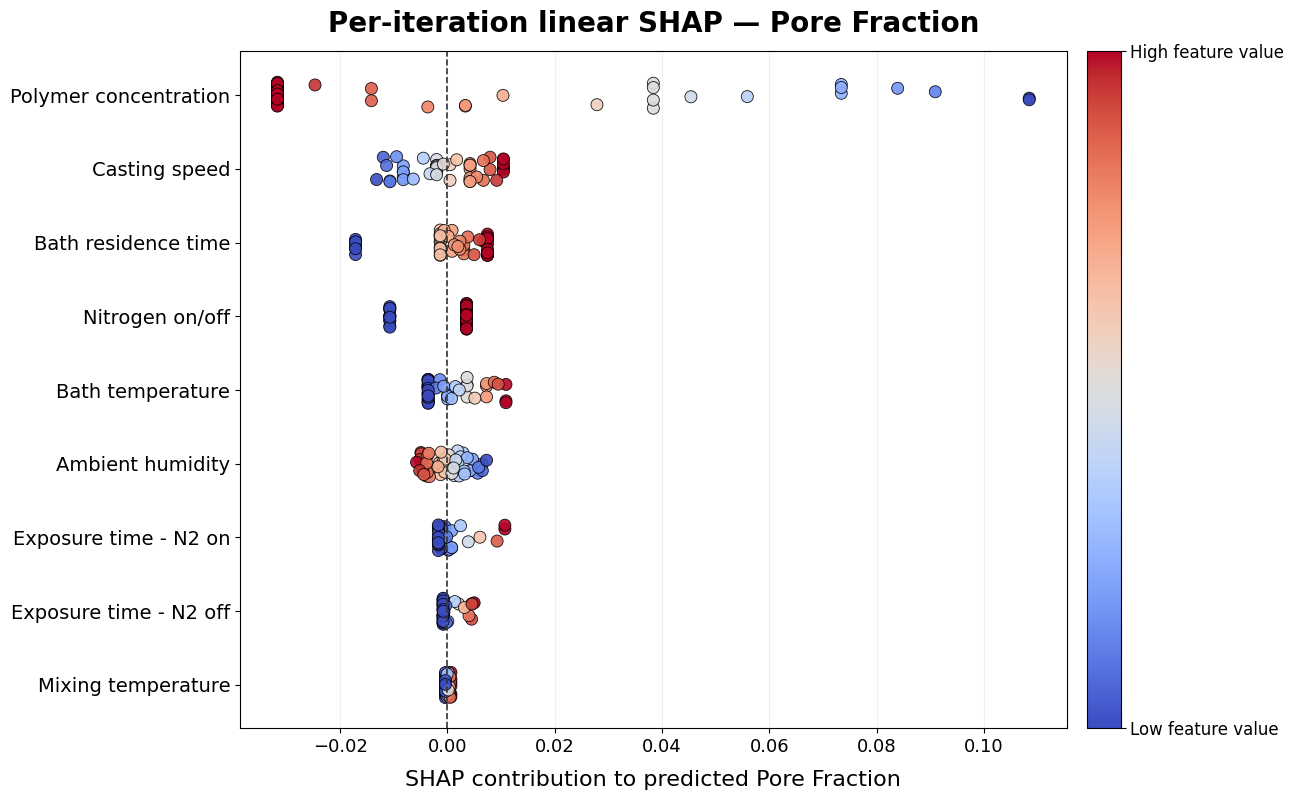

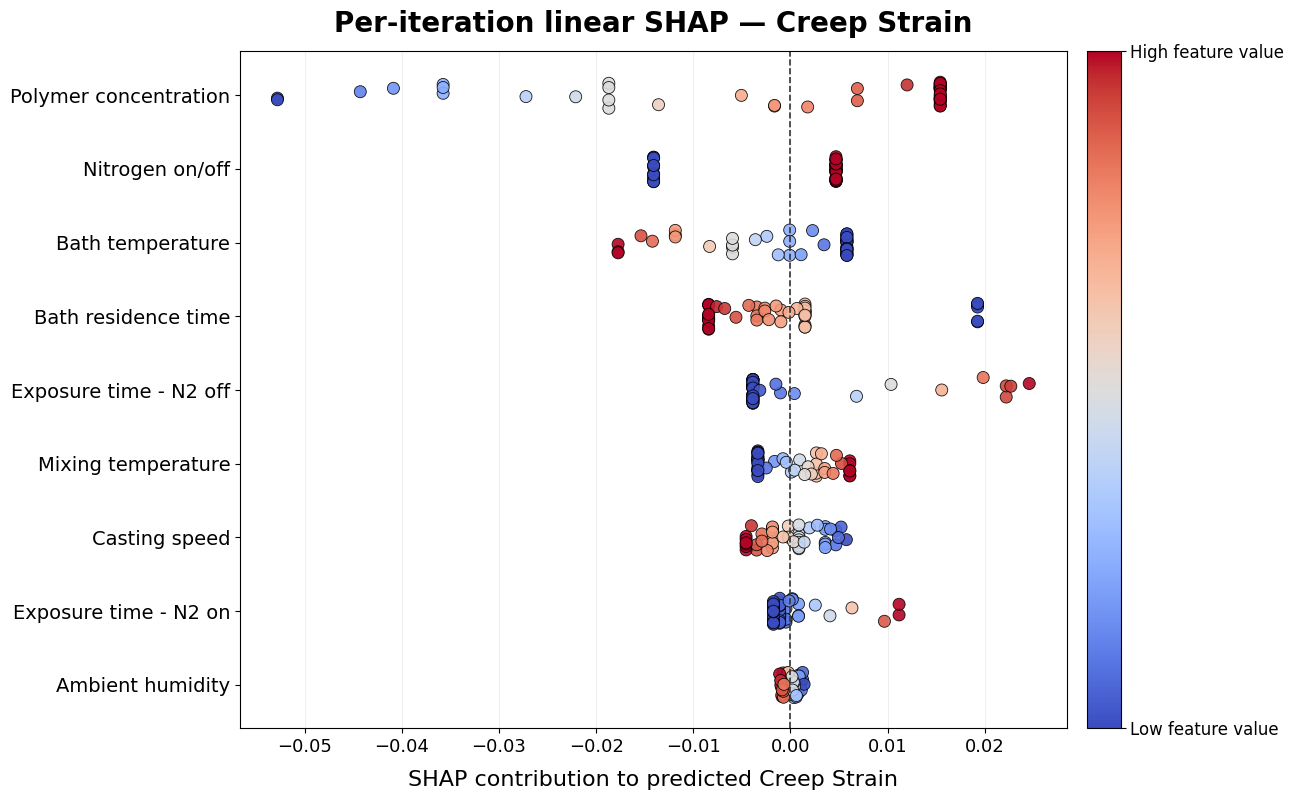

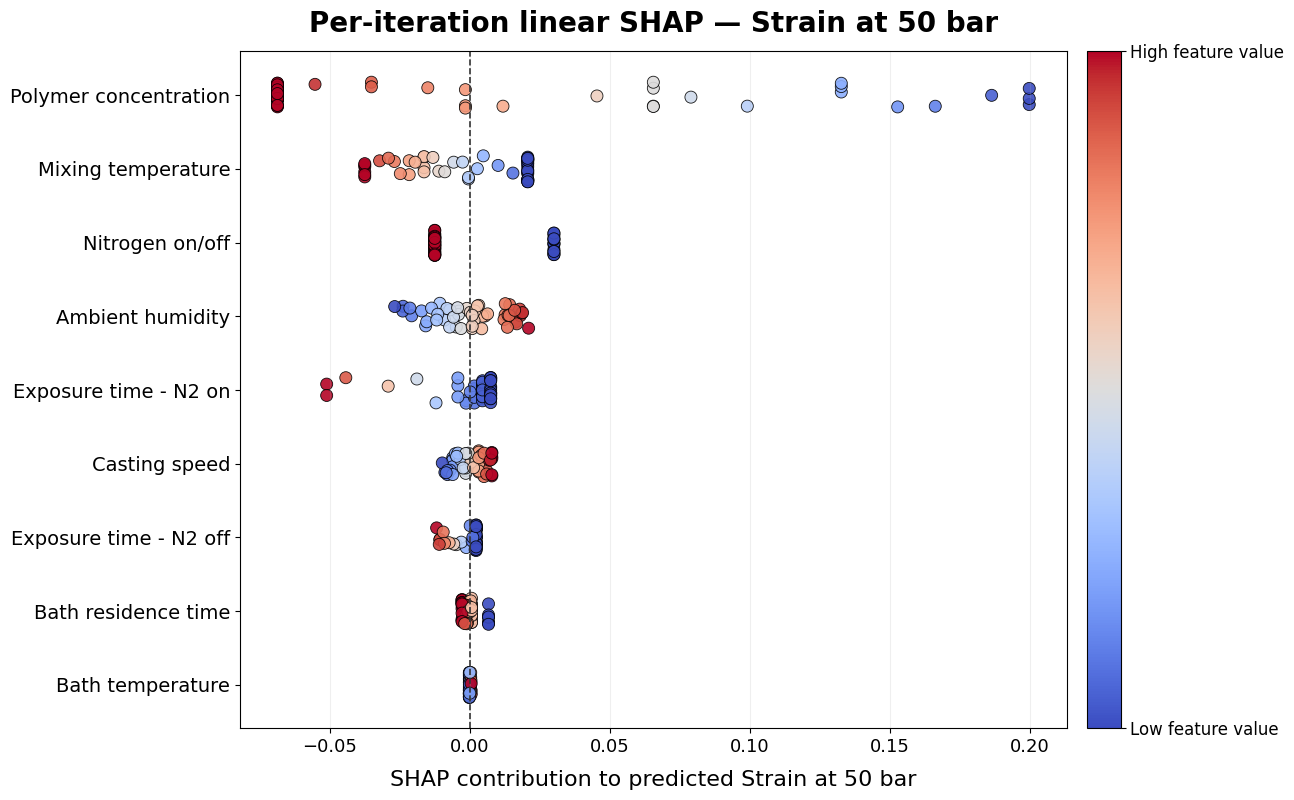

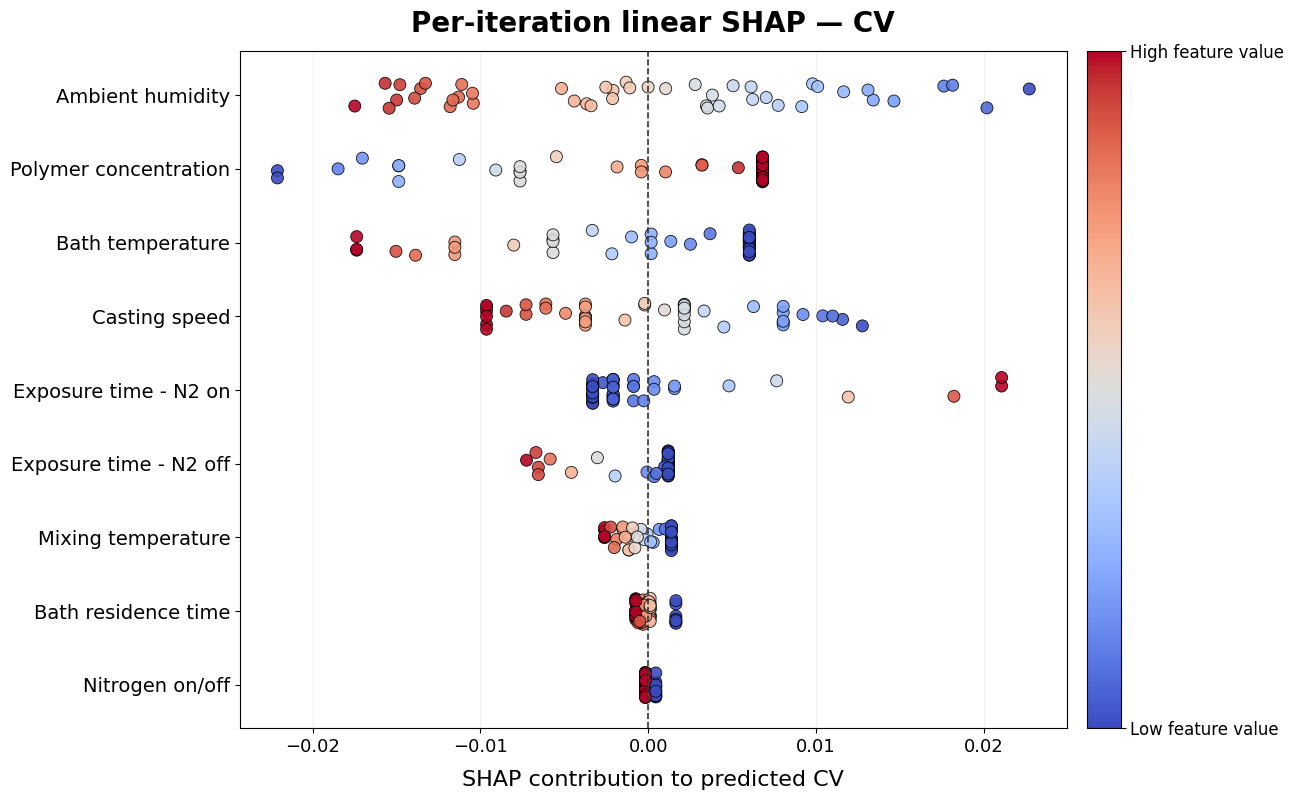

In [12]:
def plot_shap_detail(detail, property_name):
    feature_order = (detail.assign(abs_shap=detail['shap_value'].abs())
                     .groupby('feature')['abs_shap'].mean().sort_values(ascending=True).index.tolist())
    figure, axis = plt.subplots(figsize=(13, max(7, 0.9 * len(feature_order))))
    jitter_generator = np.random.RandomState(RANDOM_STATE)
    for feature_position, feature in enumerate(feature_order):
        feature_points = detail[detail['feature'] == feature].copy()
        values = feature_points['feature_value'].to_numpy(dtype=float)
        value_min, value_max = np.nanmin(values), np.nanmax(values)
        normalized_values = np.full(len(values), 0.5) if value_min == value_max else (values - value_min) / (value_max - value_min)
        vertical_positions = feature_position + jitter_generator.uniform(-0.18, 0.18, len(feature_points))
        axis.scatter(feature_points['shap_value'], vertical_positions, c=normalized_values,
                     cmap='coolwarm', vmin=0, vmax=1, s=75, edgecolor='black', linewidth=0.6, alpha=0.9)
    axis.axvline(0, color='#333333', linestyle='--', linewidth=1.2)
    axis.set_yticks(range(len(feature_order)))
    axis.set_yticklabels(feature_order, fontsize=14)
    axis.set_xlabel(f'SHAP contribution to predicted {property_name}', fontsize=16, labelpad=10)
    axis.set_title(f'Per-iteration linear SHAP — {property_name}', fontsize=20, fontweight='semibold', pad=14)
    axis.tick_params(axis='x', labelsize=13)
    axis.grid(axis='x', alpha=0.2)
    color_scale = plt.cm.ScalarMappable(norm=plt.Normalize(0, 1), cmap='coolwarm')
    color_scale.set_array([])
    colorbar = figure.colorbar(color_scale, ax=axis, pad=0.02)
    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(['Low feature value', 'High feature value'])
    colorbar.ax.tick_params(labelsize=12)
    figure.tight_layout()
    return figure, axis

figure_shap_details = {}
axes_shap_details = {}
for property_name in FEATURE_IMPORTANCE_PROPERTIES:
    detail = shap_values[shap_values['property'] == property_name].copy()
    if detail.empty:
        continue
    figure_shap_details[property_name], axes_shap_details[property_name] = plot_shap_detail(
        detail, property_name
    )
    plt.show()

In [13]:
# Optional explicit export of the enhanced figure/data; nothing is written otherwise.
if SAVE_OUTPUTS:
    output_dir = repo_root / 'EVALUATE' / 'campaign_trends_output'
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / 'campaign_data_detailed.csv'
    polymer_png = output_dir / 'campaign_properties_by_polymer.png'
    humidity_png = output_dir / 'campaign_properties_by_humidity_nitrogen.png'
    exposure_png = output_dir / 'campaign_properties_by_exposure_time.png'
    bath_png = output_dir / 'campaign_properties_by_bath_temperature.png'
    casting_png = output_dir / 'campaign_properties_by_casting_speed.png'
    importance_csv = output_dir / 'campaign_feature_importance.csv'
    importance_png = output_dir / 'campaign_feature_importance.png'
    nitrogen_exposure_png = output_dir / 'campaign_nitrogen_exposure_surfaces.png'
    humidity_exposure_png = output_dir / 'campaign_humidity_exposure_surfaces.png'
    shap_values_csv = output_dir / 'campaign_linear_shap_values.csv'
    shap_predictions_csv = output_dir / 'campaign_linear_shap_predictions.csv'
    shap_global_png = output_dir / 'campaign_linear_shap_global.png'
    campaign_detailed.to_csv(csv_path, index=False)
    figure_polymer.savefig(polymer_png, dpi=180, bbox_inches='tight')
    figure_humidity.savefig(humidity_png, dpi=180, bbox_inches='tight')
    figure_exposure.savefig(exposure_png, dpi=180, bbox_inches='tight')
    figure_bath.savefig(bath_png, dpi=180, bbox_inches='tight')
    figure_casting.savefig(casting_png, dpi=180, bbox_inches='tight')
    feature_importance.to_csv(importance_csv, index=False)
    figure_importance.savefig(importance_png, dpi=180, bbox_inches='tight')
    figure_nitrogen_exposure.savefig(nitrogen_exposure_png, dpi=180, bbox_inches='tight')
    figure_humidity_exposure.savefig(humidity_exposure_png, dpi=180, bbox_inches='tight')
    shap_values.to_csv(shap_values_csv, index=False)
    shap_predictions.to_csv(shap_predictions_csv, index=False)
    figure_shap_global.savefig(shap_global_png, dpi=180, bbox_inches='tight')
    shap_detail_paths = []
    for property_name, detail_figure in figure_shap_details.items():
        safe_property = property_name.lower().replace(' ', '_')
        detail_path = output_dir / f'campaign_linear_shap_{safe_property}.png'
        detail_figure.savefig(detail_path, dpi=180, bbox_inches='tight')
        shap_detail_paths.append(detail_path)
    all_saved_paths = [csv_path, polymer_png, humidity_png, exposure_png, bath_png, casting_png,
                       importance_csv, importance_png, nitrogen_exposure_png, humidity_exposure_png,
                       shap_values_csv, shap_predictions_csv,
                       shap_global_png] + shap_detail_paths
    print('Saved ' + '\nSaved '.join(str(path) for path in all_saved_paths))